# Adversarial Attack Suite — MobileNetV3-Large on BelgiumTSC

Comprehensive L∞ adversarial evaluation in one notebook: **FGSM**, **PGD**, **AutoAttack**,
perceptual-imperceptibility metrics, and PGD hyperparameter ablations.

**ε sweep (normalized space):** `[0.001, 0.002, 0.003, 0.005, 0.0075, 0.01, 0.02, 0.05, 0.1]`
— starts low to reveal *where* each attack becomes effective, instead of saturating at ~100% ASR.

**Two input-space pipelines, same images & checkpoint (seed=42, N=2000):**
- *Pipeline A — normalized space* (`Normalize` in transform, bare `model`): FGSM, PGD, ablations, metrics, visuals.
- *Pipeline B — [0,1] pixel space* (`NormalizedModel` wrapper): AutoAttack, with `eps_pixel = eps_norm × mean(IMAGENET_STD)`.

Both pipelines use the **same normalized-space ε convention**, so FGSM/PGD/AutoAttack ASR numbers are directly comparable.


## Part 0 — Setup & Configuration


In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, models
from torchvision.models import MobileNet_V3_Large_Weights
from torch.utils.data import DataLoader, Dataset, Subset
import pandas as pd
import numpy as np
from PIL import Image
import os
import io
import re
import json
import contextlib
import matplotlib.pyplot as plt

DATA_DIR    = 'dataset'
TEST_DIR    = os.path.join(DATA_DIR, 'BelgiumTSC_Testing', 'Testing')
CKPT_PATH   = 'best_mobilenetv3_btsd.pth'
MODEL_NAME  = 'MobileNetV3-Large'
DATASET     = 'BelgiumTSC'
NUM_CLASSES = 62
BATCH_SIZE  = 32
SEED        = 42
EVAL_SUBSET = 2000     # set None for full test set
PGD_STEPS   = 20       # 20 steps with α=ε/4 → budget 5ε >> ε for iterative refinement

EPS_VALUES     = [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.005, 0.0075, 0.01, 0.02, 0.05, 0.1]
VIS_EPS_SUBSET = [0.0005, 0.005, 0.01, 0.05, 0.1]   # representative subset (incl. sub-pixel) for the image grid
METRIC_N       = 500   # images used for perceptual metrics (shared by PGD and AutoAttack)
METRIC_BATCH   = 32

# AutoAttack is only fast when the model is FRAGILE (APGD-CE fools everything → cascade early-stops).
# At sub-pixel ε the model is robust, so AutoAttack runs the FULL APGD-T/FAB/Square cascade on the
# whole set — tens of minutes to hours per ε. AA_MIN_EPS gates which ε AutoAttack runs at; set it to
# 0.0 to run the FULL grid for AutoAttack too (slow but complete). FGSM/PGD always use the full grid.
AA_MIN_EPS = 0.0    # 0.0 = run AutoAttack on every ε (full sweep); raise it to skip slow sub-pixel ε
AA_EVAL    = 500    # AutoAttack image subset (>= METRIC_N so perceptual metrics align)
AA_EPS     = [e for e in EPS_VALUES if e >= AA_MIN_EPS]
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

# Per-channel valid bounds in normalized space (for FGSM/PGD clamping)
_mean  = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
_std   = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)
_lower = (0 - _mean) / _std
_upper = (1 - _mean) / _std

print(f'Using device: {device}')
print(f'Model: {MODEL_NAME} | Dataset: {DATASET} | PGD steps: {PGD_STEPS} | Eval subset: {EVAL_SUBSET or "full"}')
print(f'EPS grid (FGSM/PGD): {EPS_VALUES}')
print(f'AutoAttack ε (>= {AA_MIN_EPS}) on {AA_EVAL} imgs: {AA_EPS}')


Using device: cuda
Model: MobileNetV3-Large | Dataset: BelgiumTSC | PGD steps: 20 | Eval subset: 2000
EPS grid (FGSM/PGD): [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.005, 0.0075, 0.01, 0.02, 0.05, 0.1]
AutoAttack ε (>= 0.0) on 500 imgs: [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.005, 0.0075, 0.01, 0.02, 0.05, 0.1]


### Pipeline A — normalized space (FGSM / PGD / ablations / metrics / visuals)


In [2]:
class NumericImageFolder(torchvision.datasets.ImageFolder):
    """Sorts class folders by integer value. Skips non-directory entries (Readme.txt)."""
    def find_classes(self, directory):
        classes = sorted(
            (e.name for e in os.scandir(directory) if e.is_dir()),
            key=lambda x: int(x)
        )
        class_to_idx = {cls: int(cls) for cls in classes}
        return classes, class_to_idx

# Two transforms over the SAME dataset: normalized (Pipeline A) and raw [0,1] (Pipeline B)
norm_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
raw_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

full_norm = NumericImageFolder(TEST_DIR, transform=norm_transform, allow_empty=True)
full_raw  = NumericImageFolder(TEST_DIR, transform=raw_transform, allow_empty=True)
full_test_dataset = full_norm   # alias used by the eval-subset-size ablation

# Shared subset indices → Pipelines A and B evaluate the identical images
if EVAL_SUBSET:
    torch.manual_seed(SEED)
    indices = torch.randperm(len(full_norm))[:EVAL_SUBSET].tolist()
else:
    indices = list(range(len(full_norm)))

test_loader = DataLoader(Subset(full_norm, indices), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Load base model (expects ImageNet-normalized input)
model = models.mobilenet_v3_large(weights=None)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, NUM_CLASSES)
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model = model.to(device)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

criterion = nn.CrossEntropyLoss()

# Clean accuracy (Pipeline A)
correct, total = 0, 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += (model(imgs).argmax(1) == labels).sum().item()
        total += labels.size(0)
clean_acc = correct / total
print(f'Clean accuracy (Pipeline A, normalized): {clean_acc:.4f} ({clean_acc*100:.2f}%)')
print(f'Eval samples: {total}')


Clean accuracy (Pipeline A, normalized): 0.9585 (95.85%)
Eval samples: 2000


### Pipeline B — [0,1] pixel space (AutoAttack)


In [3]:
class NormalizedModel(nn.Module):
    """Wraps a model trained on ImageNet-normalized inputs.
    AutoAttack feeds images in [0, 1] pixel space; this wrapper normalizes internally."""
    def __init__(self, base_model, mean, std):
        super().__init__()
        self.model = base_model
        self.register_buffer('mean', torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor(std).view(1, 3, 1, 1))
    def forward(self, x):
        return self.model((x - self.mean) / self.std)

wrapped_model = NormalizedModel(model, IMAGENET_MEAN, IMAGENET_STD).to(device)
wrapped_model.eval()
for p in wrapped_model.parameters():
    p.requires_grad_(False)

# Same images as Pipeline A (same indices), in raw [0,1] space, held in memory for AutoAttack
raw_loader = DataLoader(Subset(full_raw, indices), batch_size=128, shuffle=False, num_workers=0)
images_list, labels_list = [], []
for imgs, lbls in raw_loader:
    images_list.append(imgs)
    labels_list.append(lbls)
images = torch.cat(images_list).to(device)
labels = torch.cat(labels_list).to(device)
print(f'AutoAttack tensor: {images.shape} | pixel range [{images.min():.3f}, {images.max():.3f}] (expected [0,1])')

# Clean accuracy (Pipeline B) and cross-check against Pipeline A
correct = 0
with torch.no_grad():
    for i in range(0, len(images), 128):
        correct += (wrapped_model(images[i:i+128]).argmax(1) == labels[i:i+128]).sum().item()
clean_acc_b = correct / len(images)
print(f'Clean accuracy (Pipeline B, wrapped): {clean_acc_b:.4f} ({clean_acc_b*100:.2f}%)')
assert abs(clean_acc_b - clean_acc) < 0.005, 'FAIL: pipelines A and B disagree on clean accuracy!'
print('PASS: both pipelines evaluate the same images with matching clean accuracy.')


AutoAttack tensor: torch.Size([2000, 3, 224, 224]) | pixel range [0.000, 1.000] (expected [0,1])
Clean accuracy (Pipeline B, wrapped): 0.9585 (95.85%)
PASS: both pipelines evaluate the same images with matching clean accuracy.


In [4]:
# Verify NormalizedModel == manual-normalize + bare model (numerical equivalence)
normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
test_batch = images[:16]
with torch.no_grad():
    preds_wrapped = wrapped_model(test_batch).argmax(1)
normalized_batch = torch.stack([normalize(img.cpu()) for img in test_batch]).to(device)
with torch.no_grad():
    preds_manual = model(normalized_batch).argmax(1)
assert (preds_wrapped == preds_manual).all(), 'FAIL: wrapper differs from manual pipeline!'
print('PASS: NormalizedModel wrapper is correct.')
print(f'Sample predictions: {preds_wrapped[:8].tolist()}')


PASS: NormalizedModel wrapper is correct.
Sample predictions: [19, 34, 59, 14, 45, 47, 61, 29]


## Part 1 — Gradient Attacks (FGSM, PGD)

FGSM (single signed-gradient step) and PGD (Madry et al.: random start + iterated FGSM + ε-ball projection), evaluated across the full ε grid in normalized space.


In [5]:
def fgsm_attack(model, images, labels, eps):
    """Fast Gradient Sign Method — single gradient step."""
    x = images.clone().requires_grad_(True)
    loss = criterion(model(x), labels)
    loss.backward()
    x_adv = (x + eps * x.grad.sign()).detach()
    x_adv = torch.clamp(x_adv, _lower.to(x_adv.device), _upper.to(x_adv.device))
    return x_adv

def pgd_attack(model, images, labels, eps, alpha, steps):
    """PGD — iterated FGSM with random start and ε-ball projection."""
    x = images + torch.empty_like(images).uniform_(-eps, eps)
    x = torch.clamp(x, images - eps, images + eps).detach()
    for _ in range(steps):
        x = x.requires_grad_(True)
        loss = criterion(model(x), labels)
        loss.backward()
        x = (x + alpha * x.grad.sign()).detach()
        x = torch.clamp(x, images - eps, images + eps)
        x = torch.clamp(x, _lower.to(x.device), _upper.to(x.device))
    return x

def evaluate_attack(attack_fn):
    """Returns (adv_acc, asr): adv_acc over all samples; asr = fraction of originally-correct fooled."""
    adv_correct = originally_correct = fooled = total = 0
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.no_grad():
            clean_mask = (model(imgs).argmax(1) == labels)
        adv = attack_fn(imgs, labels)
        with torch.no_grad():
            adv_preds = model(adv).argmax(1)
        adv_correct        += (adv_preds == labels).sum().item()
        originally_correct += clean_mask.sum().item()
        fooled             += (clean_mask & (adv_preds != labels)).sum().item()
        total              += labels.size(0)
    adv_acc = adv_correct / total
    asr     = fooled / originally_correct if originally_correct > 0 else 0.0
    return adv_acc, asr

print('FGSM, PGD, evaluate_attack defined.')


FGSM, PGD, evaluate_attack defined.


In [6]:
fgsm_results = {}
print(f'{"ε":>7} | {"Adv Acc":>9} | {"ASR":>9} | {"Drop":>9}')
print('-' * 45)
for eps in EPS_VALUES:
    adv_acc, asr = evaluate_attack(lambda imgs, labels, e=eps: fgsm_attack(model, imgs, labels, e))
    fgsm_results[eps] = {'acc': adv_acc, 'asr': asr}
    print(f'{eps:>7.4f} | {adv_acc*100:>8.2f}% | {asr*100:>8.2f}% | {(clean_acc-adv_acc)*100:>8.2f}pp')
print(f'\nClean baseline: {clean_acc*100:.2f}%')


      ε |   Adv Acc |       ASR |      Drop
---------------------------------------------
 0.0001 |    92.55% |     3.44% |     3.30pp
 0.0002 |    88.45% |     7.72% |     7.40pp
 0.0005 |    75.65% |    21.07% |    20.20pp
 0.0010 |    60.60% |    36.78% |    35.25pp
 0.0020 |    45.80% |    52.22% |    50.05pp
 0.0030 |    38.70% |    59.62% |    57.15pp
 0.0050 |    33.45% |    65.10% |    62.40pp
 0.0075 |    33.50% |    65.05% |    62.35pp
 0.0100 |    35.65% |    62.81% |    60.20pp
 0.0200 |    48.80% |    49.09% |    47.05pp
 0.0500 |    65.15% |    32.03% |    30.70pp
 0.1000 |    66.70% |    30.83% |    29.15pp

Clean baseline: 95.85%


In [7]:
pgd_results = {}
print(f'{"ε":>7} | {"Adv Acc":>9} | {"ASR":>9} | {"Drop":>9}  [steps={PGD_STEPS}]')
print('-' * 55)
for eps in EPS_VALUES:
    alpha = eps / 4
    adv_acc, asr = evaluate_attack(lambda imgs, labels, e=eps, a=alpha: pgd_attack(model, imgs, labels, e, a, PGD_STEPS))
    pgd_results[eps] = {'acc': adv_acc, 'asr': asr}
    print(f'{eps:>7.4f} | {adv_acc*100:>8.2f}% | {asr*100:>8.2f}% | {(clean_acc-adv_acc)*100:>8.2f}pp')
print(f'\nClean baseline: {clean_acc*100:.2f}%')


      ε |   Adv Acc |       ASR |      Drop  [steps=20]
-------------------------------------------------------
 0.0001 |    92.25% |     3.76% |     3.60pp
 0.0002 |    86.50% |     9.75% |     9.35pp
 0.0005 |    61.30% |    36.05% |    34.55pp
 0.0010 |    29.80% |    68.91% |    66.05pp
 0.0020 |     6.30% |    93.43% |    89.55pp
 0.0030 |     1.85% |    98.07% |    94.00pp
 0.0050 |     0.20% |    99.79% |    95.65pp
 0.0075 |     0.05% |    99.95% |    95.80pp
 0.0100 |     0.00% |   100.00% |    95.85pp
 0.0200 |     0.00% |   100.00% |    95.85pp
 0.0500 |     0.00% |   100.00% |    95.85pp
 0.1000 |     0.00% |   100.00% |    95.85pp

Clean baseline: 95.85%


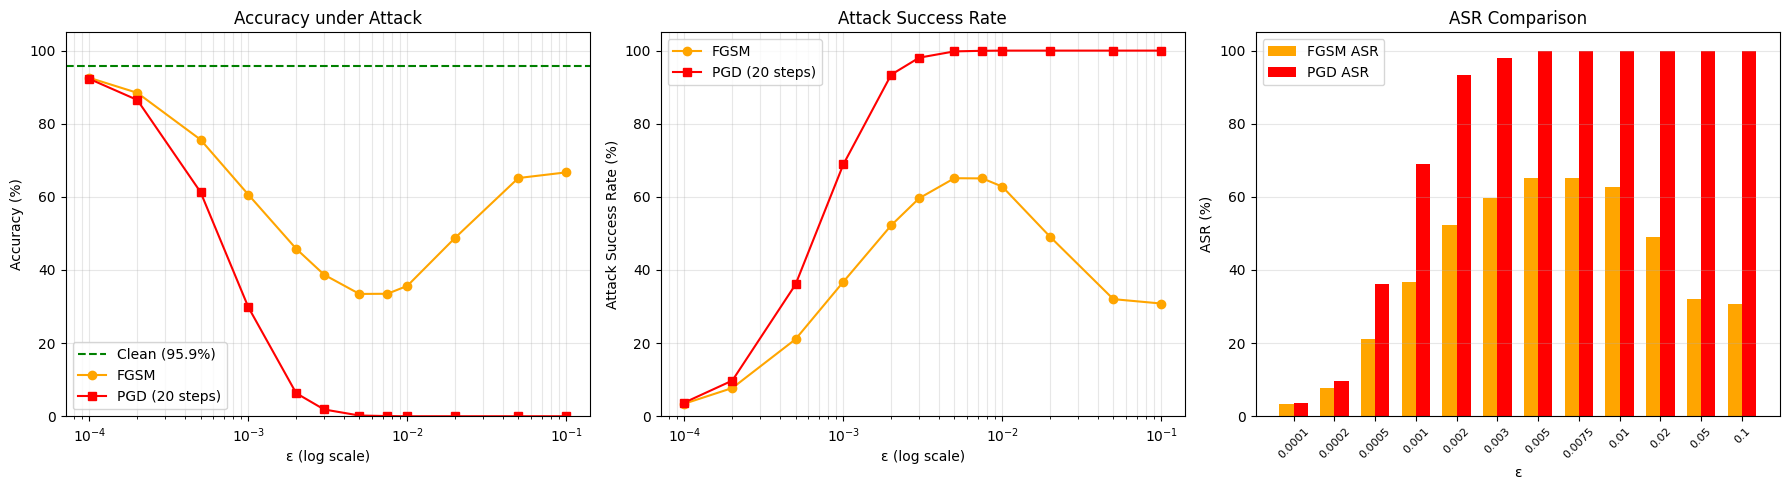


      ε |    Clean |  FGSM Acc |  FGSM ASR |  PGD Acc |  PGD ASR
 0.0001 |   95.85% |    92.55% |     3.44% |   92.25% |    3.76%
 0.0002 |   95.85% |    88.45% |     7.72% |   86.50% |    9.75%
 0.0005 |   95.85% |    75.65% |    21.07% |   61.30% |   36.05%
 0.0010 |   95.85% |    60.60% |    36.78% |   29.80% |   68.91%
 0.0020 |   95.85% |    45.80% |    52.22% |    6.30% |   93.43%
 0.0030 |   95.85% |    38.70% |    59.62% |    1.85% |   98.07%
 0.0050 |   95.85% |    33.45% |    65.10% |    0.20% |   99.79%
 0.0075 |   95.85% |    33.50% |    65.05% |    0.05% |   99.95%
 0.0100 |   95.85% |    35.65% |    62.81% |    0.00% |  100.00%
 0.0200 |   95.85% |    48.80% |    49.09% |    0.00% |  100.00%
 0.0500 |   95.85% |    65.15% |    32.03% |    0.00% |  100.00%
 0.1000 |   95.85% |    66.70% |    30.83% |    0.00% |  100.00%


In [8]:
eps_list  = EPS_VALUES
fgsm_accs = [fgsm_results[e]['acc'] * 100 for e in eps_list]
pgd_accs  = [pgd_results[e]['acc']  * 100 for e in eps_list]
fgsm_asrs = [fgsm_results[e]['asr'] * 100 for e in eps_list]
pgd_asrs  = [pgd_results[e]['asr']  * 100 for e in eps_list]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax = axes[0]
ax.axhline(clean_acc * 100, color='green', linestyle='--', label=f'Clean ({clean_acc*100:.1f}%)')
ax.semilogx(eps_list, fgsm_accs, 'o-', color='orange', label='FGSM')
ax.semilogx(eps_list, pgd_accs,  's-', color='red',    label=f'PGD ({PGD_STEPS} steps)')
ax.set_xlabel('ε (log scale)'); ax.set_ylabel('Accuracy (%)'); ax.set_title('Accuracy under Attack')
ax.legend(); ax.set_ylim(0, 105); ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.semilogx(eps_list, fgsm_asrs, 'o-', color='orange', label='FGSM')
ax.semilogx(eps_list, pgd_asrs,  's-', color='red',    label=f'PGD ({PGD_STEPS} steps)')
ax.set_xlabel('ε (log scale)'); ax.set_ylabel('Attack Success Rate (%)'); ax.set_title('Attack Success Rate')
ax.legend(); ax.set_ylim(0, 105); ax.grid(True, which='both', alpha=0.3)

ax = axes[2]
x = np.arange(len(eps_list)); w = 0.35
ax.bar(x - w/2, fgsm_asrs, w, label='FGSM ASR', color='orange')
ax.bar(x + w/2, pgd_asrs,  w, label='PGD ASR',  color='red')
ax.set_xticks(x); ax.set_xticklabels([str(e) for e in eps_list], rotation=45, fontsize=8)
ax.set_xlabel('ε'); ax.set_ylabel('ASR (%)'); ax.set_title('ASR Comparison')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print(f'\n{"":=<70}')
print(f'{"ε":>7} | {"Clean":>8} | {"FGSM Acc":>9} | {"FGSM ASR":>9} | {"PGD Acc":>8} | {"PGD ASR":>8}')
print(f'{"":=<70}')
for e in eps_list:
    print(f'{e:>7.4f} | {clean_acc*100:>7.2f}% | {fgsm_results[e]["acc"]*100:>8.2f}% | {fgsm_results[e]["asr"]*100:>8.2f}% | {pgd_results[e]["acc"]*100:>7.2f}% | {pgd_results[e]["asr"]*100:>7.2f}%')
print(f'{"":=<70}')


## Part 2 — AutoAttack (gold-standard L∞)

Parameter-free ensemble (APGD-CE, APGD-T, FAB-T, Square) in [0,1] pixel space via the wrapper, with `eps_pixel = eps_norm × mean(IMAGENET_STD)`. Run at every ε; verbose log captured to parse the sub-attack cascade. AutoAttack is the slow part — early termination is fast for fragile models.


In [9]:
import sys
from autoattack import AutoAttack

aa_results = {}   # eps_norm -> {robust_acc, asr, eps_pixel, px_of_255, log, x_adv_path, foolmask_path}

# AutoAttack runs ONLY at ε >= AA_MIN_EPS, on a small subset (AA_EVAL). At sub-pixel ε the model is
# robust, so AutoAttack would run its full APGD-T/FAB/Square cascade on the whole set — hours per ε.
# FGSM/PGD already cover those ε on the full set (Parts 1 & 3).
aa_imgs, aa_lbls = images[:AA_EVAL], labels[:AA_EVAL]

# Advs are cached to DISK (not RAM): the metrics cell loads one ε at a time. The cache persists for the
# session (so the metrics cell is re-runnable); the final cell clears it on demand.
AA_ADV_CACHE = '_aa_adv_cache'
os.makedirs(AA_ADV_CACHE, exist_ok=True)
for _f in os.listdir(AA_ADV_CACHE):   # clear stale advs from any previous run
    os.remove(os.path.join(AA_ADV_CACHE, _f))

# Tee: AutoAttack's verbose output goes live to the notebook AND into a buffer we parse later.
class _Tee:
    def __init__(self, *streams): self.streams = streams
    def write(self, s):
        for st in self.streams:
            st.write(s); st.flush()
    def flush(self):
        for st in self.streams: st.flush()
_real_stdout = sys.stdout

print(f'Running AutoAttack L-inf (standard) on {AA_EVAL} images at ε in {AA_EPS}')
if AA_MIN_EPS <= min(EPS_VALUES):
    print('WARNING: full grid includes sub-pixel ε where the model is robust — AutoAttack runs its full')
    print('         APGD-T/FAB/Square cascade there, which can take tens of minutes to hours per ε.')
else:
    print(f'(ε < {AA_MIN_EPS} skipped — robust regime, full cascade is slow; see FGSM/PGD for those ε.)')
print('=' * 72)
for ei, eps_norm in enumerate(AA_EPS):
    eps_pixel = float(eps_norm * np.mean(IMAGENET_STD))
    px_of_255 = eps_pixel * 255
    print(f'\n--- eps_norm={eps_norm}  eps_pixel={eps_pixel:.6f}  ({px_of_255:.4f}/255) ---')
    log_buf = io.StringIO()
    with contextlib.redirect_stdout(_Tee(_real_stdout, log_buf)):   # live + captured
        adversary = AutoAttack(wrapped_model, norm='Linf', eps=eps_pixel, version='standard', verbose=True)
        x_adv = adversary.run_standard_evaluation(aa_imgs, aa_lbls, bs=64)
    log_text = log_buf.getvalue()
    with torch.no_grad():
        clean_preds = torch.cat([wrapped_model(aa_imgs[i:i+128]).argmax(1) for i in range(0, len(aa_imgs), 128)])
        adv_preds   = torch.cat([wrapped_model(x_adv[i:i+128]).argmax(1) for i in range(0, len(x_adv), 128)])
    clean_mask = (clean_preds == aa_lbls)
    fooled_mask = clean_mask & (adv_preds != aa_lbls)   # clean-correct AND adv-wrong = successfully fooled
    robust_acc = (adv_preds == aa_lbls).float().mean().item()
    asr = fooled_mask.float().sum().item() / clean_mask.float().sum().item()
    # Cache the first METRIC_N AutoAttack advs ([0,1] space) AND their fooled-mask to disk for the
    # perceptual metrics (Part 4). Metrics are computed only over the fooled subset (Option A).
    adv_path  = os.path.join(AA_ADV_CACHE, f'aa_adv_{ei:02d}.pt')
    mask_path = os.path.join(AA_ADV_CACHE, f'aa_foolmask_{ei:02d}.pt')
    torch.save(x_adv[:METRIC_N].detach().cpu(), adv_path)
    torch.save(fooled_mask[:METRIC_N].detach().cpu(), mask_path)
    aa_results[eps_norm] = {'robust_acc': robust_acc, 'asr': asr, 'eps_pixel': eps_pixel, 'px_of_255': px_of_255, 'log': log_text,
                            'x_adv_path': adv_path, 'foolmask_path': mask_path}
    del x_adv
    print(f'  >>> Robust Acc: {robust_acc*100:.2f}%  |  ASR: {asr*100:.2f}%')
print('\n' + '=' * 72)
print('AutoAttack sweep complete.')


Running AutoAttack L-inf (standard) on 500 images at ε in [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.005, 0.0075, 0.01, 0.02, 0.05, 0.1]
         APGD-T/FAB/Square cascade there, which can take tens of minutes to hours per ε.

--- eps_norm=0.0001  eps_pixel=0.000023  (0.0058/255) ---
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 96.00%
apgd-ce - 1/8 - 3 out of 64 successfully perturbed
apgd-ce - 2/8 - 2 out of 64 successfully perturbed
apgd-ce - 3/8 - 5 out of 64 successfully perturbed
apgd-ce - 4/8 - 1 out of 64 successfully perturbed
apgd-ce - 5/8 - 3 out of 64 successfully perturbed
apgd-ce - 6/8 - 1 out of 64 successfully perturbed
apgd-ce - 7/8 - 2 out of 64 successfully perturbed
apgd-ce - 8/8 - 1 out of 32 successfully perturbed
robust accuracy after APGD-CE: 92.40% (total time 10.7 s)
apgd-t - 1/8 - 0 out of 64 successfully perturbed
apgd-t - 2/8 - 0 out of 64 successfully perturbed
apgd-t - 3/8 -

In [10]:
# PGD vs AutoAttack comparison (both in normalized-space ε; AutoAttack only at ε >= AA_MIN_EPS)
print(f'{MODEL_NAME} on {DATASET} — PGD vs AutoAttack  (AA on {AA_EVAL} imgs, ε >= {AA_MIN_EPS})')
print(f'{"ε":>7} | {"PGD ASR":>9} | {"AA ASR":>9} | {"Diff":>8} | Verdict')
print('-' * 64)
max_gap = 0.0
for e in AA_EPS:
    pgd_asr = pgd_results[e]['asr'] * 100
    aa_asr  = aa_results[e]['asr'] * 100
    diff    = aa_asr - pgd_asr
    if abs(diff) > abs(max_gap):
        max_gap = diff
    verdict = 'PGD optimal' if abs(diff) < 1.0 else ('minor gap' if abs(diff) < 5.0 else 'AA stronger')
    print(f'{e:>7.4f} | {pgd_asr:>8.2f}% | {aa_asr:>8.2f}% | {diff:>+7.2f}pp | {verdict}')
print('-' * 64)
print(f'Max PGD–AutoAttack gap: {max_gap:+.2f} pp')


MobileNetV3-Large on BelgiumTSC — PGD vs AutoAttack  (AA on 500 imgs, ε >= 0.0)
      ε |   PGD ASR |    AA ASR |     Diff | Verdict
----------------------------------------------------------------
 0.0001 |     3.76% |     3.75% |   -0.01pp | PGD optimal
 0.0002 |     9.75% |    11.25% |   +1.50pp | minor gap
 0.0005 |    36.05% |    41.67% |   +5.62pp | AA stronger
 0.0010 |    68.91% |    80.62% |  +11.72pp | AA stronger
 0.0020 |    93.43% |    99.58% |   +6.16pp | AA stronger
 0.0030 |    98.07% |   100.00% |   +1.93pp | minor gap
 0.0050 |    99.79% |   100.00% |   +0.21pp | PGD optimal
 0.0075 |    99.95% |   100.00% |   +0.05pp | PGD optimal
 0.0100 |   100.00% |   100.00% |   +0.00pp | PGD optimal
 0.0200 |   100.00% |   100.00% |   +0.00pp | PGD optimal
 0.0500 |   100.00% |   100.00% |   +0.00pp | PGD optimal
 0.1000 |   100.00% |   100.00% |   +0.00pp | PGD optimal
----------------------------------------------------------------
Max PGD–AutoAttack gap: +11.72 pp


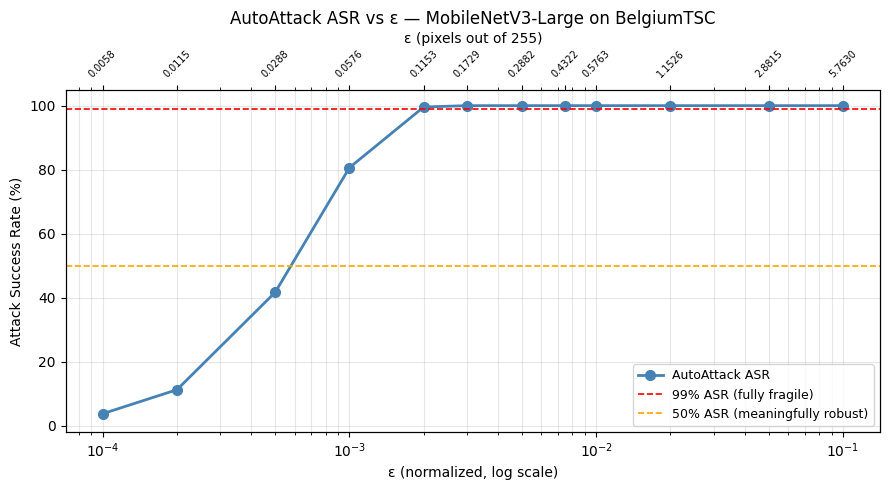

In [11]:
eps_vals   = AA_EPS   # AutoAttack ran only at ε >= AA_MIN_EPS
aa_asr_pct = [aa_results[e]['asr'] * 100 for e in eps_vals]
px255_vals = [aa_results[e]['px_of_255'] for e in eps_vals]

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(eps_vals, aa_asr_pct, 'o-', color='steelblue', linewidth=2, markersize=7, label='AutoAttack ASR')
ax.axhline(99, color='red',    linestyle='--', linewidth=1.2, label='99% ASR (fully fragile)')
ax.axhline(50, color='orange', linestyle='--', linewidth=1.2, label='50% ASR (meaningfully robust)')
ax.set_xlabel('ε (normalized, log scale)'); ax.set_ylabel('Attack Success Rate (%)')
ax.set_title(f'AutoAttack ASR vs ε — {MODEL_NAME} on {DATASET}')
ax.set_ylim(-2, 105); ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)
ax2 = ax.twiny(); ax2.set_xscale('log'); ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(eps_vals); ax2.set_xticklabels([f'{v:.4f}' for v in px255_vals], rotation=45, fontsize=7)
ax2.set_xlabel('ε (pixels out of 255)', fontsize=10)
plt.tight_layout(); plt.show()


In [12]:
# Sub-attack cascade at the smallest ε (among those AutoAttack ran) where it is NOT at 100% ASR
breakdown_eps = next((e for e in AA_EPS if aa_results[e]['asr'] < 1.0), None)
if breakdown_eps is None:
    print('AutoAttack is at 100% ASR for all tested ε — APGD-CE alone suffices everywhere.')
else:
    log = aa_results[breakdown_eps]['log']
    def parse_acc(label, text):
        m = re.search(rf'{re.escape(label)}[:\s]+([\d.]+)%', text, re.IGNORECASE)
        return float(m.group(1)) if m else None
    initial = parse_acc('initial accuracy', log)
    a_ce = parse_acc('robust accuracy after APGD-CE', log)
    a_t  = parse_acc('robust accuracy after APGD-T', log)
    a_fb = parse_acc('robust accuracy after FAB-T', log)
    a_sq = parse_acc('robust accuracy after SQUARE', log)
    final = aa_results[breakdown_eps]['robust_acc'] * 100
    def defeated(before, after):
        if before is None or after is None: return 'N/A'
        return str(round((before - after) / 100 * AA_EVAL))
    r = aa_results[breakdown_eps]
    print(f'ε={breakdown_eps} (pixel={r["eps_pixel"]:.6f}, {r["px_of_255"]:.4f}/255) sub-attack cascade:')
    print(f'  Initial robust acc:   {initial:>8.2f}%')
    if a_ce is not None: print(f'  After APGD-CE:        {a_ce:>8.2f}%   (defeated ~{defeated(initial, a_ce)} images)')
    if a_t  is not None: print(f'  After APGD-T:         {a_t:>8.2f}%   (defeated ~{defeated(a_ce, a_t)} images)')
    if a_fb is not None: print(f'  After FAB-T:          {a_fb:>8.2f}%   (defeated ~{defeated(a_t, a_fb)} images)')
    if a_sq is not None: print(f'  After Square:         {a_sq:>8.2f}%   (defeated ~{defeated(a_fb, a_sq)} images)')
    print(f'  (counts are out of the AA_EVAL={AA_EVAL} AutoAttack subset)')
    print(f'  Final robust acc:     {final:>8.2f}%')
    if a_ce is not None and a_ce <= 0.1:
        print('  => APGD-CE alone achieves near-zero robust acc; later attacks not needed.')
    elif a_ce is not None and a_ce > 0.5:
        print('  => APGD-CE insufficient alone; targeted/boundary/black-box attacks contribute.')


ε=0.0001 (pixel=0.000023, 0.0058/255) sub-attack cascade:
  Initial robust acc:      96.00%
  After APGD-CE:           92.40%   (defeated ~18 images)
  After APGD-T:            92.40%   (defeated ~0 images)
  After FAB-T:             92.40%   (defeated ~0 images)
  After Square:            92.40%   (defeated ~0 images)
  (counts are out of the AA_EVAL=500 AutoAttack subset)
  Final robust acc:        92.40%
  => APGD-CE insufficient alone; targeted/boundary/black-box attacks contribute.


## Part 3 — Combined Attack Comparison

FGSM vs PGD vs AutoAttack on a single log-scale ε axis — the view that shows *from which ε* each attack becomes effective — plus the robustness-floor readout from the gold-standard AutoAttack curve.


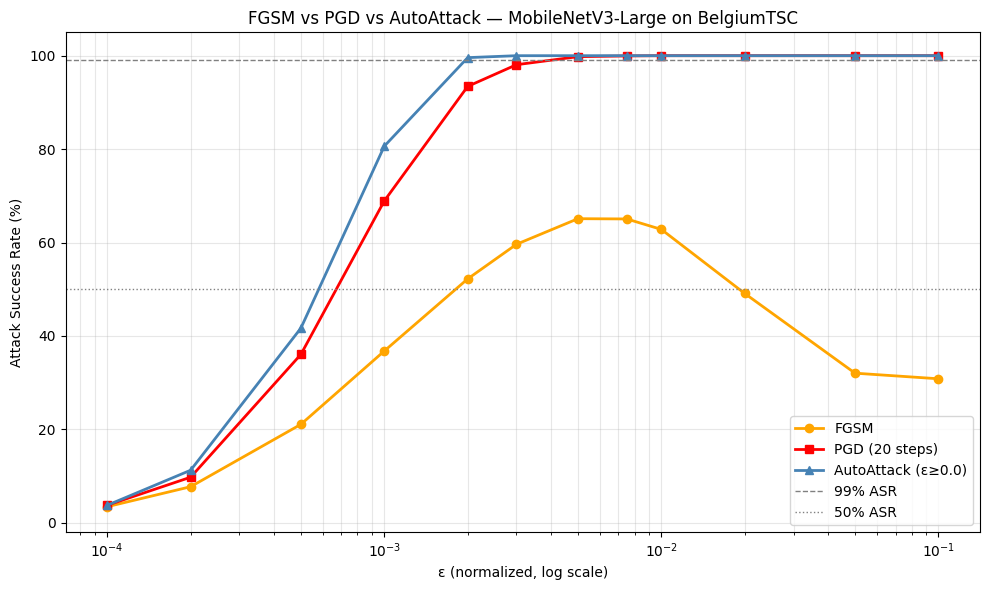

Saved: mobilenetv3_bel_asr_vs_eps.png

Robustness floor (AutoAttack):
  Smallest ε with ASR ≥ 99%: 0.002
  Largest ε with ASR < 50%:  0.0005


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
# FGSM/PGD cover the full ε grid; AutoAttack only ε >= AA_MIN_EPS (its line starts there)
ax.semilogx(EPS_VALUES, [fgsm_results[e]['asr']*100 for e in EPS_VALUES], 'o-', color='orange', linewidth=2, label='FGSM')
ax.semilogx(EPS_VALUES, [pgd_results[e]['asr']*100  for e in EPS_VALUES], 's-', color='red',    linewidth=2, label=f'PGD ({PGD_STEPS} steps)')
ax.semilogx(AA_EPS,     [aa_results[e]['asr']*100   for e in AA_EPS],     '^-', color='steelblue', linewidth=2, label=f'AutoAttack (ε≥{AA_MIN_EPS})')
ax.axhline(99, color='gray', linestyle='--', linewidth=1, label='99% ASR')
ax.axhline(50, color='gray', linestyle=':',  linewidth=1, label='50% ASR')
ax.set_xlabel('ε (normalized, log scale)'); ax.set_ylabel('Attack Success Rate (%)')
ax.set_title(f'FGSM vs PGD vs AutoAttack — {MODEL_NAME} on {DATASET}')
ax.set_ylim(-2, 105); ax.legend(fontsize=10); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('mobilenetv3_bel_asr_vs_eps.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved: mobilenetv3_bel_asr_vs_eps.png')

# Robustness floor (from AutoAttack, the strongest attack; evaluated over AA_EPS)
ff = next((e for e in AA_EPS if aa_results[e]['asr'] >= 0.99), None)
rb = next((e for e in reversed(AA_EPS) if aa_results[e]['asr'] < 0.50), None)
print('\nRobustness floor (AutoAttack):')
print(f'  Smallest ε with ASR ≥ 99%: {ff if ff is not None else "none in AA range"}')
print(f'  Largest ε with ASR < 50%:  {rb if rb is not None else "none in AA range"}')
aa_min_e = AA_EPS[0]
if aa_results[aa_min_e]['asr'] >= 0.99:
    print(f'  NOTE: AutoAttack ASR is already {aa_results[aa_min_e]["asr"]*100:.2f}% at its smallest tested ε={aa_min_e} '
          f'({aa_results[aa_min_e]["px_of_255"]:.4f}/255). For ε<{AA_MIN_EPS}, see the FGSM/PGD curves above.')


## Part 4 — Perceptual Imperceptibility Metrics

PSNR, SSIM, LPIPS (AlexNet) of the PGD perturbations, measured **only on the images PGD actually fooled** (clean-correct → adv-wrong) — this is the **Option A** view: the perceptibility of the perturbations that succeeded, not a worst-case ε bound. Unfooled images (e.g. MSE=0 at tiny ε) are excluded so they can't inflate PSNR to ∞. Thresholds: PSNR > 30 dB, SSIM > 0.95, LPIPS < 0.1. Reference: Madry ε = 8/255.


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\RA-02\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\RA-02\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\RA-02\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lpips\weights\v0.1\alex.pth
      ε |    N_fooled |         PSNR (dB) |              SSIM |             LPIPS   [PGD, fooled-only]
----------------------------------------------------------------------------------------
 0.0001 |   17/500    |  51.15 ± 0.01 dB | 0.9965 ± 0.0007   | 0.0000 ± 0.0000
 0.0002 |   52/500    |  51.14 ± 0.02 dB | 0.9964 ± 0.0007   | 0.0000 ± 0.0000
 0.0005 |  174/500    |  51.15 ± 0.05 dB | 0.9965 ± 0.0006   | 0.0000 ± 0.0000
 0.0010 |  327/500    |  51.16 ± 0.07 dB | 0.9966 ± 0.0006   | 0.0000 ± 0.0000
 0.0020 |  450/500    |  51.15 ± 0.09 dB | 0.9967 ± 0.0006   | 0.0000 ± 0.0000
 0.0030 |  468/500    |  51.16 ± 0.10 dB | 0.9967 ± 0.0006   | 0.0000 ± 0.0000
 0.0050 |  479/500    |  51.16 ± 0.11 dB | 0.9967 ± 0.0006   | 0.0001 ± 0.0001
 0.0075 |  480/500    |  51.16 ± 0.13 dB | 0.9967 ± 0.0006   | 0.0004 ± 0.0003
 0.0100 |  480/500    |  51.18 ± 0.13 dB | 0.9967 ± 0.0

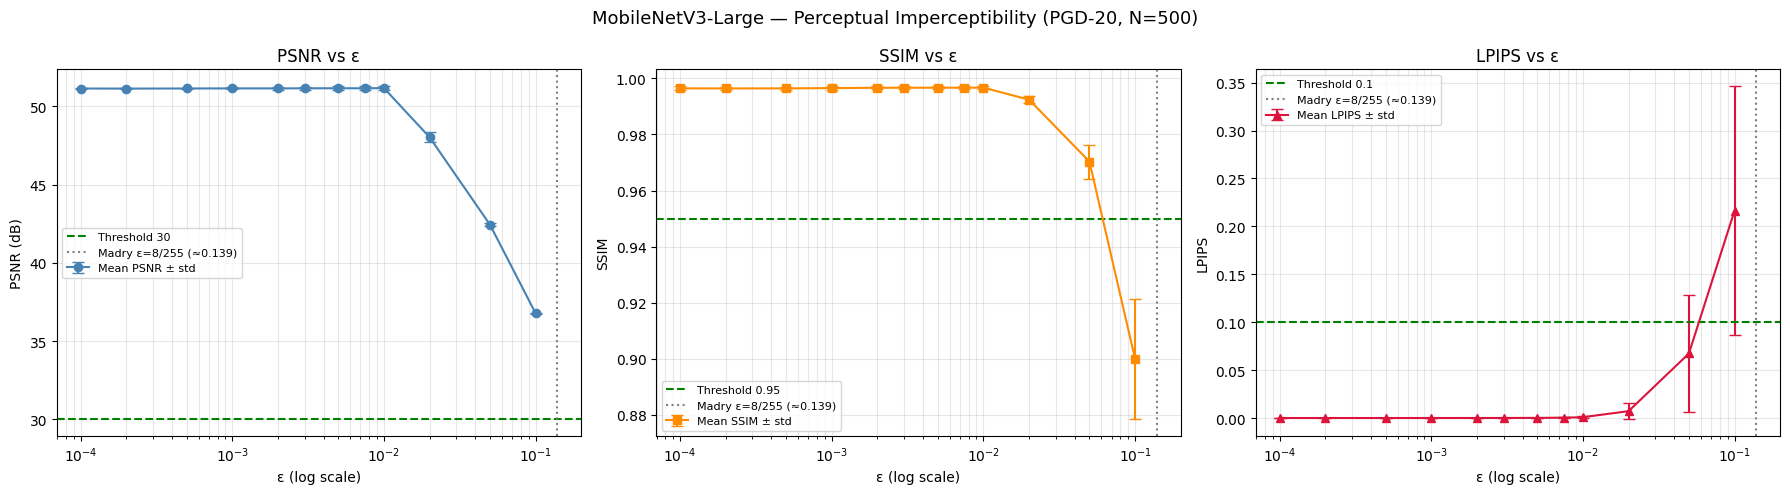

In [14]:
import subprocess, sys, math
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lpips', '-q'], check=True)
import lpips
from skimage.metrics import structural_similarity as ssim_fn

# PGD perceptual metrics — computed in NORMALIZED space (Pipeline A): de-normalize via _inv_norm
# to uint8, then PSNR/SSIM on [0,255]. (The AutoAttack metrics below are computed in [0,1] pixel
# space, Pipeline B — the two spaces are kept separate and never mixed.)
MADRY_EPS    = (8 / 255) / np.mean(IMAGENET_STD)

_inv_norm = transforms.Normalize(mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)], std=[1/s for s in IMAGENET_STD])
lpips_fn = lpips.LPIPS(net='alex').to(device)

def _to_uint8(t):
    return (_inv_norm(t.cpu()).permute(1, 2, 0).clamp(0, 1).numpy() * 255).astype('uint8')
def _psnr(a, b):
    mse = ((a.astype(float) - b.astype(float)) ** 2).mean()
    return 10 * math.log10(255**2 / mse) if mse > 0 else float('inf')
def _ssim(a, b):
    return ssim_fn(a, b, channel_axis=2, data_range=255)

_imgs_list, _lbls_list = [], []
for _imgs, _lbls in test_loader:
    for i in range(_imgs.size(0)):
        _imgs_list.append(_imgs[i]); _lbls_list.append(_lbls[i])
        if len(_imgs_list) == METRIC_N: break
    if len(_imgs_list) == METRIC_N: break
_all_imgs   = torch.stack(_imgs_list).to(device)
_all_labels = torch.stack(_lbls_list).to(device)

NAN_METRIC = {'pixel_delta': float('nan'), 'psnr_mean': float('nan'), 'psnr_std': float('nan'), 'ssim_mean': float('nan'), 'ssim_std': float('nan'), 'lpips_mean': float('nan'), 'lpips_std': float('nan'), 'n_fooled': 0}
metric_results = {}
print(f'{"ε":>7} | {"N_fooled":>11} | {"PSNR (dB)":>17} | {"SSIM":>17} | {"LPIPS":>17}   [PGD, fooled-only]')
print('-' * 88)
for eps in EPS_VALUES:
    alpha = eps / 4
    adv_chunks = [pgd_attack(model, _all_imgs[s:s+METRIC_BATCH], _all_labels[s:s+METRIC_BATCH], eps, alpha, PGD_STEPS) for s in range(0, METRIC_N, METRIC_BATCH)]
    adv_all = torch.cat(adv_chunks, dim=0)
    # Fooled subset: clean-correct AND adv-wrong (normalized space, bare model)
    with torch.no_grad():
        clean_preds = torch.cat([model(_all_imgs[s:s+METRIC_BATCH]).argmax(1) for s in range(0, METRIC_N, METRIC_BATCH)])
        adv_preds   = torch.cat([model(adv_all[s:s+METRIC_BATCH]).argmax(1) for s in range(0, METRIC_N, METRIC_BATCH)])
    fooled = (clean_preds == _all_labels) & (adv_preds != _all_labels)
    n_fooled = int(fooled.sum().item())
    pixel_delta = eps * 255 * np.mean(IMAGENET_STD)
    if n_fooled == 0:
        metric_results[eps] = {**NAN_METRIC, 'pixel_delta': pixel_delta}
        print(f'{eps:>7.4f} | {0:>4d}/{METRIC_N:<6d} | no PGD successes at this ε — perceptual metrics N/A')
        continue
    fidx = fooled.nonzero(as_tuple=True)[0]
    orig_f, adv_f = _all_imgs[fidx], adv_all[fidx]
    psnrs, ssims, lpips_vals = [], [], []
    for i in range(n_fooled):
        o, a = _to_uint8(orig_f[i]), _to_uint8(adv_f[i])
        psnrs.append(_psnr(o, a)); ssims.append(_ssim(o, a))
    for s in range(0, n_fooled, METRIC_BATCH):
        e = min(s + METRIC_BATCH, n_fooled)
        o01 = _inv_norm(orig_f[s:e]).clamp(0,1) * 2 - 1
        a01 = _inv_norm(adv_f[s:e]).clamp(0,1)  * 2 - 1
        with torch.no_grad():
            lp = lpips_fn(o01, a01).view(-1).cpu().numpy()
        lpips_vals.extend(lp.tolist())
    metric_results[eps] = {'pixel_delta': pixel_delta, 'psnr_mean': np.mean(psnrs), 'psnr_std': np.std(psnrs), 'ssim_mean': np.mean(ssims), 'ssim_std': np.std(ssims), 'lpips_mean': np.mean(lpips_vals), 'lpips_std': np.std(lpips_vals), 'n_fooled': n_fooled}
    r = metric_results[eps]
    print(f'{eps:>7.4f} | {n_fooled:>4d}/{METRIC_N:<6d} | {r["psnr_mean"]:>6.2f} ± {r["psnr_std"]:.2f} dB | {r["ssim_mean"]:.4f} ± {r["ssim_std"]:.4f}   | {r["lpips_mean"]:.4f} ± {r["lpips_std"]:.4f}')

psnr_m = [metric_results[e]['psnr_mean'] for e in EPS_VALUES]; psnr_s = [metric_results[e]['psnr_std'] for e in EPS_VALUES]
ssim_m = [metric_results[e]['ssim_mean'] for e in EPS_VALUES]; ssim_s = [metric_results[e]['ssim_std'] for e in EPS_VALUES]
lpips_m = [metric_results[e]['lpips_mean'] for e in EPS_VALUES]; lpips_s = [metric_results[e]['lpips_std'] for e in EPS_VALUES]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{MODEL_NAME} — Perceptual Imperceptibility (PGD-{PGD_STEPS}, N={METRIC_N})', fontsize=13)
for ax, (m, s, thr, name, fmt, col) in zip(axes, [(psnr_m, psnr_s, 30, 'PSNR (dB)', 'o-', 'steelblue'), (ssim_m, ssim_s, 0.95, 'SSIM', 's-', 'darkorange'), (lpips_m, lpips_s, 0.1, 'LPIPS', '^-', 'crimson')]):
    ax.errorbar(EPS_VALUES, m, yerr=s, fmt=fmt, color=col, capsize=4, label=f'Mean {name.split()[0]} ± std')
    ax.axhline(thr, color='green', linestyle='--', linewidth=1.5, label=f'Threshold {thr}')
    ax.axvline(MADRY_EPS, color='gray', linestyle=':', linewidth=1.5, label=f'Madry ε=8/255 (≈{MADRY_EPS:.3f})')
    ax.set_xscale('log'); ax.set_xlabel('ε (log scale)'); ax.set_ylabel(name); ax.set_title(f'{name.split()[0]} vs ε')
    ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()


### AutoAttack Perceptual Metrics — Option A (actual fooling perturbations)

Same PSNR / SSIM / LPIPS as above (same `ssim_fn` and the same `lpips_fn` instance), but on the **actual AutoAttack adversarial examples** in **[0,1] pixel space** (Pipeline B), and measured **only over the images AutoAttack actually fooled**. AutoAttack returns the *unchanged* original for inputs it can't fool — those have MSE=0 (PSNR=∞) and would corrupt the mean — so they are excluded. AutoAttack also searches *within* the ε-ball rather than always pushing to the boundary, so these reflect the real successful perturbations, not a worst-case ε bound. ε with zero successes (possible at the smallest ε) are left as gaps in the plot.


      ε |    N_fooled |         PSNR (dB) |              SSIM |             LPIPS   [AutoAttack, [0,1], fooled-only]
------------------------------------------------------------------------------------------
 0.0001 |   18/500    |  93.10 ± 0.08 dB | 1.0000 ± 0.0000   | 0.0000 ± 0.0000
 0.0002 |   54/500    |  87.12 ± 0.09 dB | 1.0000 ± 0.0000   | 0.0000 ± 0.0000
 0.0005 |  200/500    |  79.26 ± 0.12 dB | 1.0000 ± 0.0000   | 0.0000 ± 0.0000
 0.0010 |  387/500    |  73.38 ± 0.20 dB | 1.0000 ± 0.0000   | 0.0000 ± 0.0000
 0.0020 |  478/500    |  67.67 ± 0.33 dB | 0.9999 ± 0.0000   | 0.0000 ± 0.0000
 0.0030 |  480/500    |  64.47 ± 0.43 dB | 0.9998 ± 0.0000   | 0.0001 ± 0.0000
 0.0050 |  480/500    |  60.58 ± 0.54 dB | 0.9995 ± 0.0001   | 0.0002 ± 0.0001
 0.0075 |  480/500    |  57.55 ± 0.59 dB | 0.9991 ± 0.0001   | 0.0005 ± 0.0004
 0.0100 |  480/500    |  55.40 ± 0.57 dB | 0.9985 ± 0.0002   | 0.0011 ± 0.0010
 0.0200 |  480/500    |  50.08 ± 0.43 dB | 0.9948 ± 0.0010   | 0.0076 ± 0.0087
 0

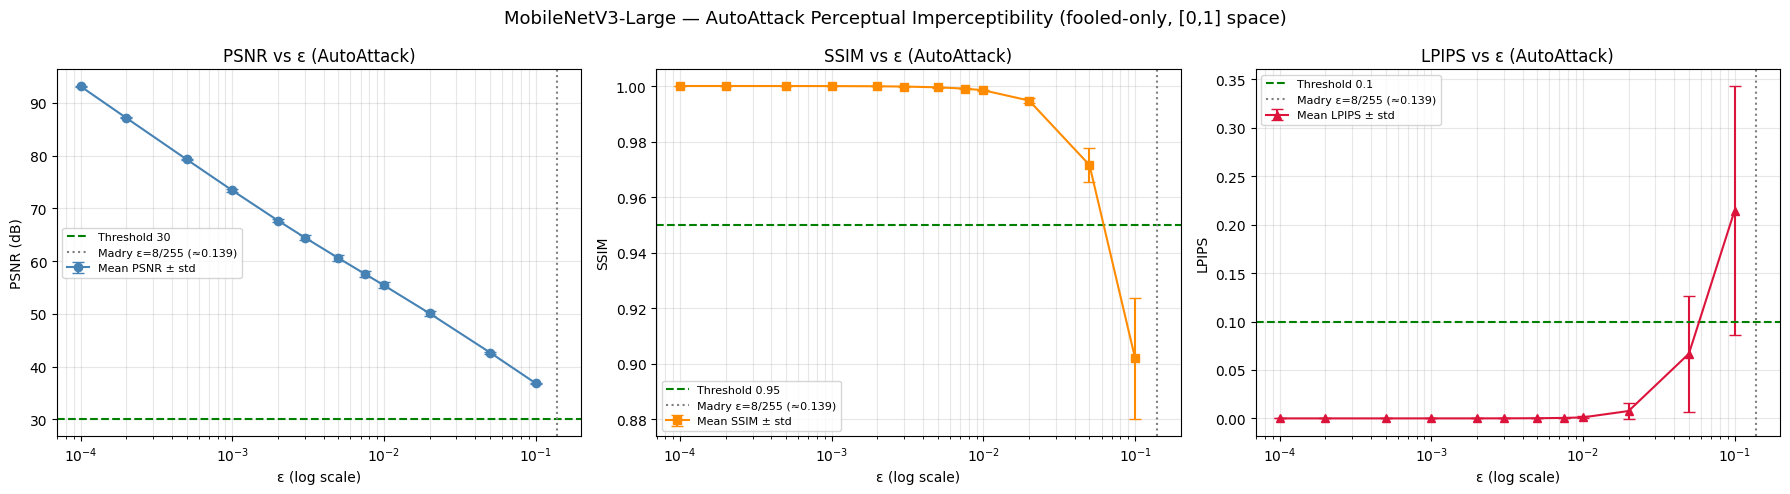

In [15]:
# AutoAttack perceptual metrics — computed in [0,1] PIXEL space (Pipeline B).
# Originals are the raw [0,1] `images` tensor; advs are the saved AutoAttack outputs (also [0,1]).
# PSNR uses data_range=1.0, SSIM uses data_range=1.0, LPIPS expects [-1,1] so we feed 2*x-1.
# (Contrast: the PGD cell above works in NORMALIZED space via _inv_norm → uint8. Spaces are not mixed.)
orig_01 = images[:METRIC_N]   # raw [0,1] originals, same order/images as the saved AutoAttack advs

try:                       # reuse results across re-runs to skip recompute
    aa_metric_results
except NameError:
    aa_metric_results = {}
AA_NAN_METRIC = {'psnr_mean': float('nan'), 'psnr_std': float('nan'), 'ssim_mean': float('nan'), 'ssim_std': float('nan'), 'lpips_mean': float('nan'), 'lpips_std': float('nan'), 'n_fooled': 0}
print(f'{"ε":>7} | {"N_fooled":>11} | {"PSNR (dB)":>17} | {"SSIM":>17} | {"LPIPS":>17}   [AutoAttack, [0,1], fooled-only]')
print('-' * 90)
for eps in AA_EPS:   # AutoAttack ran only at ε >= AA_MIN_EPS
    if eps in aa_metric_results:   # already computed on a prior run — skip recompute
        r = aa_metric_results[eps]
        if r['n_fooled'] == 0:
            print(f'{eps:>7.4f} | {0:>4d}/{METRIC_N:<6d} | no successful attacks at this ε — perceptual metrics N/A  (cached)')
        else:
            print(f'{eps:>7.4f} | {r["n_fooled"]:>4d}/{METRIC_N:<6d} | {r["psnr_mean"]:>6.2f} ± {r["psnr_std"]:.2f} dB | {r["ssim_mean"]:.4f} ± {r["ssim_std"]:.4f}   | {r["lpips_mean"]:.4f} ± {r["lpips_std"]:.4f}  (cached)')
        continue
    _p, _pm = aa_results[eps]['x_adv_path'], aa_results[eps]['foolmask_path']
    if not os.path.exists(_p) or not os.path.exists(_pm):
        raise FileNotFoundError(f'{_p} / {_pm} missing — re-run the AutoAttack sweep cell to regenerate the cache.')
    adv_01 = torch.load(_p).to(device)    # first METRIC_N AutoAttack advs in [0,1]
    mask   = torch.load(_pm).to(device)   # bool: which of those were successfully fooled
    n_fooled = int(mask.sum().item())
    if n_fooled == 0:   # nothing fooled at this ε (possible at the very smallest) — leave a gap
        aa_metric_results[eps] = dict(AA_NAN_METRIC)
        print(f'{eps:>7.4f} | {0:>4d}/{METRIC_N:<6d} | no successful attacks at this ε — perceptual metrics N/A')
        del adv_01, mask
        continue
    orig_f, adv_f = orig_01[mask], adv_01[mask]   # fooled subset only (Option A)
    psnrs, ssims, lpips_vals = [], [], []
    for i in range(n_fooled):
        o = orig_f[i].permute(1, 2, 0).clamp(0, 1).cpu().numpy()
        a = adv_f[i].permute(1, 2, 0).clamp(0, 1).cpu().numpy()
        mse = ((o - a) ** 2).mean()
        psnrs.append(10 * math.log10(1.0 / mse) if mse > 0 else float('inf'))
        ssims.append(ssim_fn(o, a, channel_axis=2, data_range=1.0))
    for s in range(0, n_fooled, METRIC_BATCH):
        e = min(s + METRIC_BATCH, n_fooled)
        o11 = orig_f[s:e].clamp(0, 1) * 2 - 1
        a11 = adv_f[s:e].clamp(0, 1) * 2 - 1
        with torch.no_grad():
            lp = lpips_fn(o11, a11).view(-1).cpu().numpy()
        lpips_vals.extend(lp.tolist())
    aa_metric_results[eps] = {'psnr_mean': np.mean(psnrs), 'psnr_std': np.std(psnrs), 'ssim_mean': np.mean(ssims), 'ssim_std': np.std(ssims), 'lpips_mean': np.mean(lpips_vals), 'lpips_std': np.std(lpips_vals), 'n_fooled': n_fooled}
    r = aa_metric_results[eps]
    print(f'{eps:>7.4f} | {n_fooled:>4d}/{METRIC_N:<6d} | {r["psnr_mean"]:>6.2f} ± {r["psnr_std"]:.2f} dB | {r["ssim_mean"]:.4f} ± {r["ssim_std"]:.4f}   | {r["lpips_mean"]:.4f} ± {r["lpips_std"]:.4f}')
    del adv_01, mask, orig_f, adv_f   # free RAM each iteration; cached files on disk persist for re-runs

aa_psnr_m = [aa_metric_results[e]['psnr_mean'] for e in AA_EPS]; aa_psnr_s = [aa_metric_results[e]['psnr_std'] for e in AA_EPS]
aa_ssim_m = [aa_metric_results[e]['ssim_mean'] for e in AA_EPS]; aa_ssim_s = [aa_metric_results[e]['ssim_std'] for e in AA_EPS]
aa_lpips_m = [aa_metric_results[e]['lpips_mean'] for e in AA_EPS]; aa_lpips_s = [aa_metric_results[e]['lpips_std'] for e in AA_EPS]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{MODEL_NAME} — AutoAttack Perceptual Imperceptibility (fooled-only, [0,1] space)', fontsize=13)
for ax, (m, s, thr, name, fmt, col) in zip(axes, [(aa_psnr_m, aa_psnr_s, 30, 'PSNR (dB)', 'o-', 'steelblue'), (aa_ssim_m, aa_ssim_s, 0.95, 'SSIM', 's-', 'darkorange'), (aa_lpips_m, aa_lpips_s, 0.1, 'LPIPS', '^-', 'crimson')]):
    ax.errorbar(AA_EPS, m, yerr=s, fmt=fmt, color=col, capsize=4, label=f'Mean {name.split()[0]} ± std')
    ax.axhline(thr, color='green', linestyle='--', linewidth=1.5, label=f'Threshold {thr}')
    ax.axvline(MADRY_EPS, color='gray', linestyle=':', linewidth=1.5, label=f'Madry ε=8/255 (≈{MADRY_EPS:.3f})')
    ax.set_xscale('log'); ax.set_xlabel('ε (log scale)'); ax.set_ylabel(name); ax.set_title(f'{name.split()[0]} vs ε (AutoAttack)')
    ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()


In [16]:
# Side-by-side: PGD (normalized space) vs AutoAttack ([0,1] space) perceptual metrics at each ε.
# Option A: each attack is measured ONLY on the images it itself fooled (counts may differ), so this
# compares the perceptibility of each attack's successful perturbations. 'nan' = no successes at that ε.
print(f'{"ε":>7} | {"PGD nf":>6} | {"AA nf":>6} | {"PGD PSNR":>9} | {"AA PSNR":>9} | {"PGD SSIM":>9} | {"AA SSIM":>9} | {"PGD LPIPS":>10} | {"AA LPIPS":>9}')
print('-' * 104)
for e in EPS_VALUES:
    p = metric_results[e]
    a = aa_metric_results.get(e)   # AutoAttack only ran at ε >= AA_MIN_EPS
    if a is None:
        print(f'{e:>7.4f} | {p["n_fooled"]:>6d} | {"—":>6} | {p["psnr_mean"]:>8.2f} | {"—":>8} | {p["ssim_mean"]:>9.4f} | {"—":>9} | {p["lpips_mean"]:>10.4f} | {"—":>9}   (AA skipped)')
        continue
    print(f'{e:>7.4f} | {p["n_fooled"]:>6d} | {a["n_fooled"]:>6d} | {p["psnr_mean"]:>8.2f} | {a["psnr_mean"]:>8.2f} | {p["ssim_mean"]:>9.4f} | {a["ssim_mean"]:>9.4f} | {p["lpips_mean"]:>10.4f} | {a["lpips_mean"]:>9.4f}')
print('\nEach attack is scored on its own fooled set (Option A); both are constrained to the same ε-ball.')
print(f'(AutoAttack ran only at ε >= {AA_MIN_EPS}; “—” marks ε where only the fast attacks were evaluated.)')
print('AutoAttack often uses less than the full budget, so its successful perturbations can be slightly less perceptible.')


      ε | PGD nf |  AA nf |  PGD PSNR |   AA PSNR |  PGD SSIM |   AA SSIM |  PGD LPIPS |  AA LPIPS
--------------------------------------------------------------------------------------------------------
 0.0001 |     17 |     18 |    51.15 |    93.10 |    0.9965 |    1.0000 |     0.0000 |    0.0000
 0.0002 |     52 |     54 |    51.14 |    87.12 |    0.9964 |    1.0000 |     0.0000 |    0.0000
 0.0005 |    174 |    200 |    51.15 |    79.26 |    0.9965 |    1.0000 |     0.0000 |    0.0000
 0.0010 |    327 |    387 |    51.16 |    73.38 |    0.9966 |    1.0000 |     0.0000 |    0.0000
 0.0020 |    450 |    478 |    51.15 |    67.67 |    0.9967 |    0.9999 |     0.0000 |    0.0000
 0.0030 |    468 |    480 |    51.16 |    64.47 |    0.9967 |    0.9998 |     0.0000 |    0.0001
 0.0050 |    479 |    480 |    51.16 |    60.58 |    0.9967 |    0.9995 |     0.0001 |    0.0002
 0.0075 |    480 |    480 |    51.16 |    57.55 |    0.9967 |    0.9991 |     0.0004 |    0.0005
 0.0100 |    480 |  

### Imperceptibility caveat

Imperceptibility holds cleanly for **ε ≤ 0.05** — across both attacks the metrics stay on the imperceptible side of every threshold (PSNR > 30 dB, SSIM > 0.95, LPIPS < 0.1). **ε = 0.10 is the perceptible end of the range**: at this budget SSIM can fall below ~0.9 and LPIPS can exceed 0.1, so perturbations at ε=0.10 are *not* claimed to be imperceptible — treat it as the visible stress point of the sweep, and read off imperceptible-attack conclusions at ε ≤ 0.05.


## Part 5 — Adversarial Example Visualization

Original vs FGSM vs PGD across a representative ε subset, for a few correctly-classified images from distinct classes. red = fooled, green = still correct.


Collected 4 images from classes: [19, 59, 14, 45]


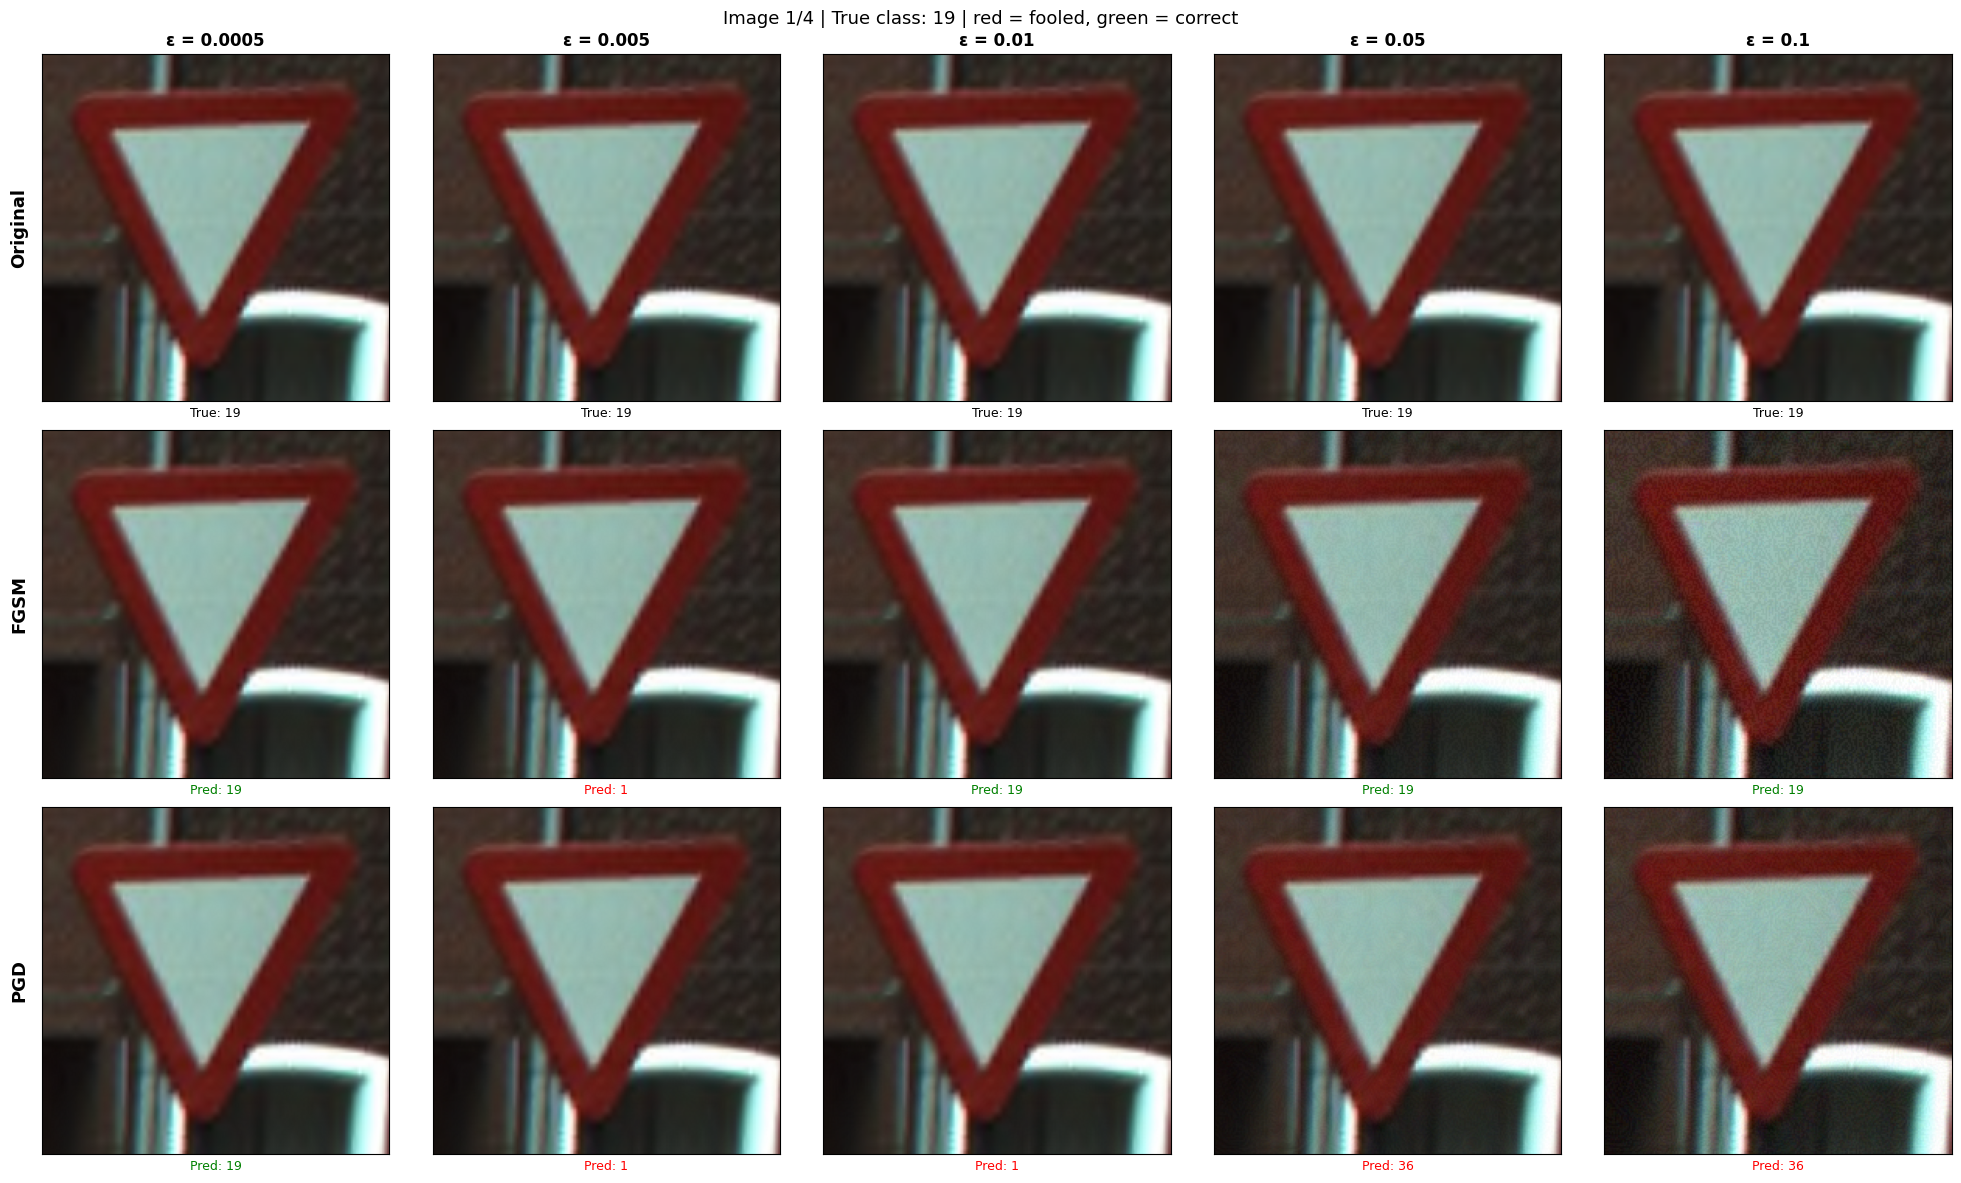

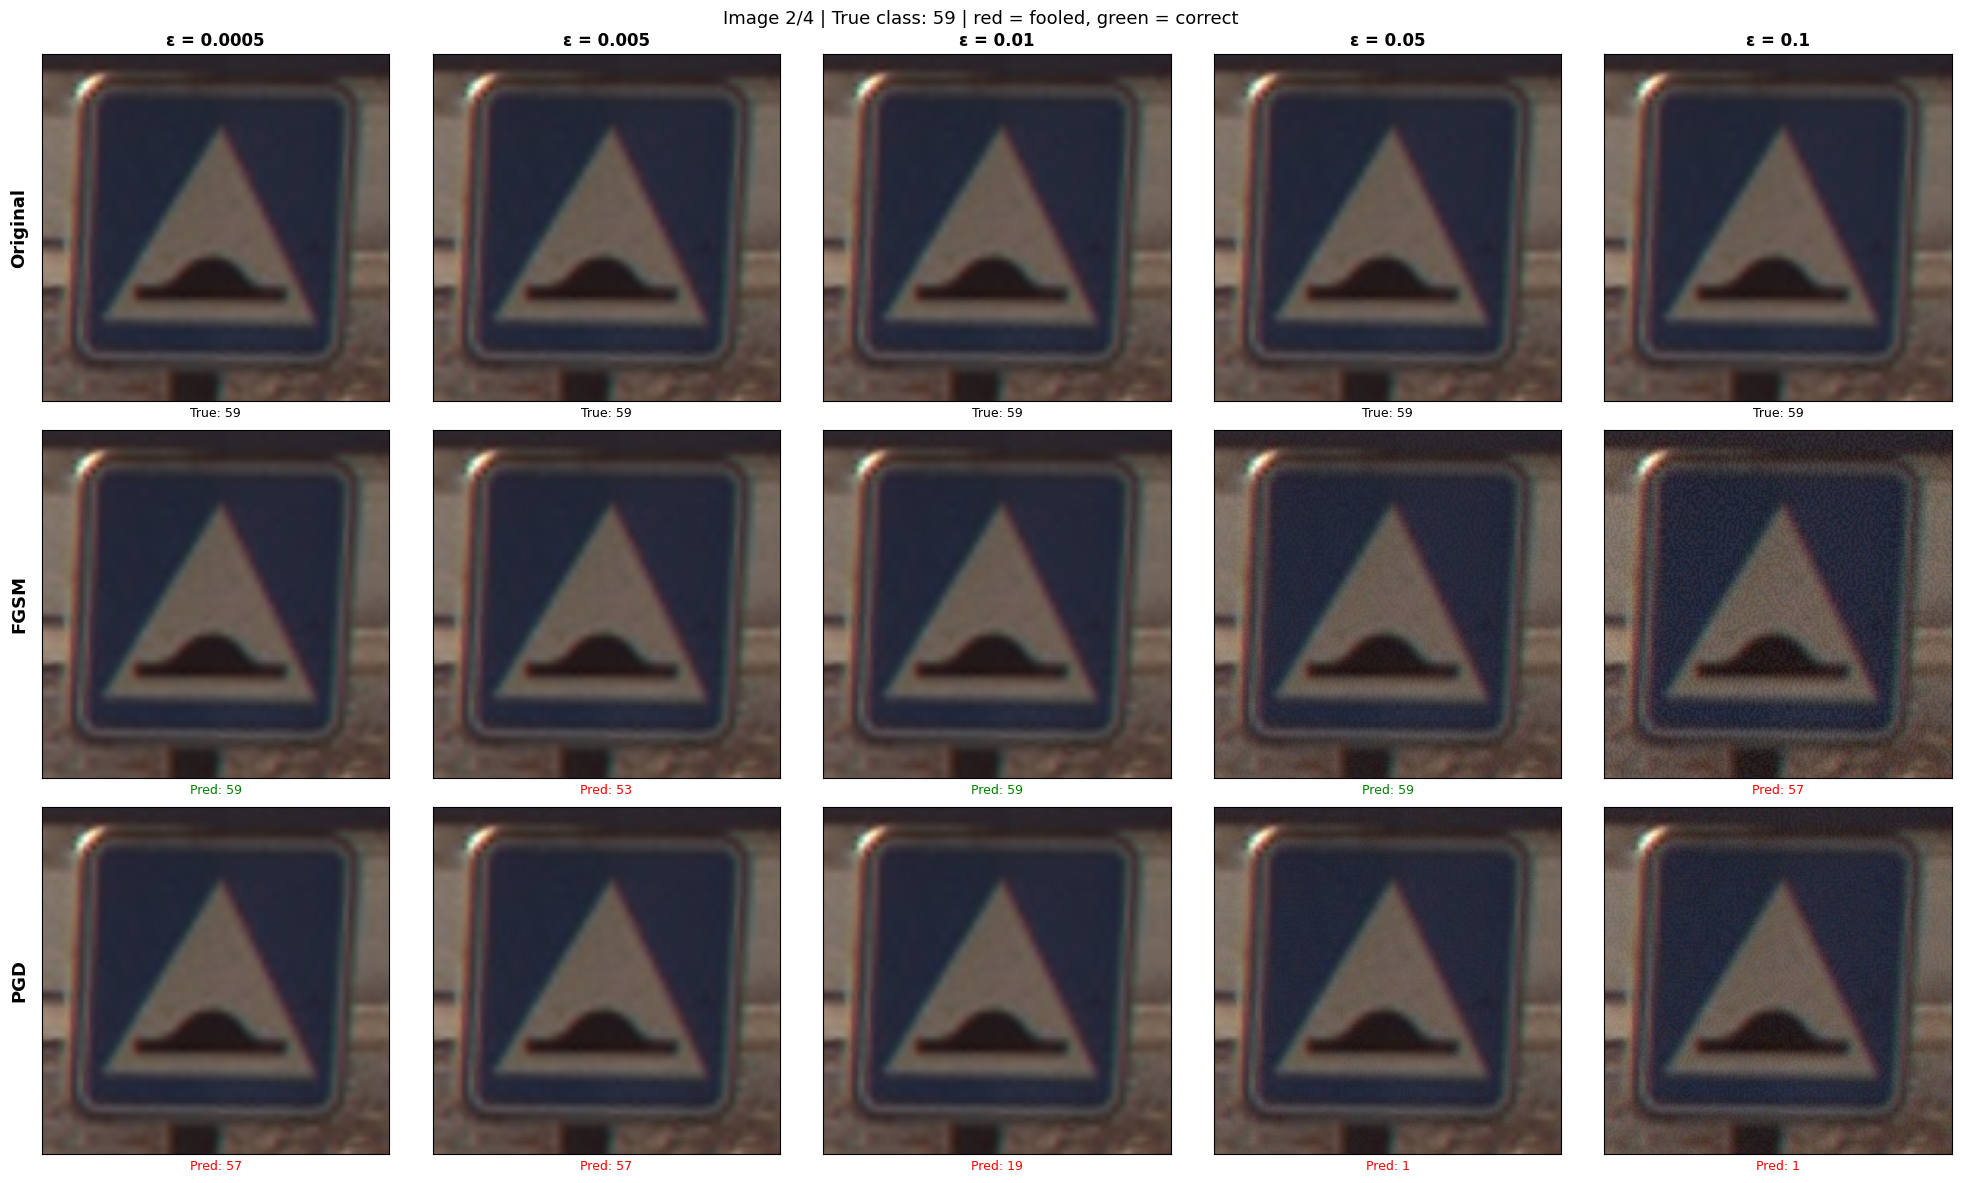

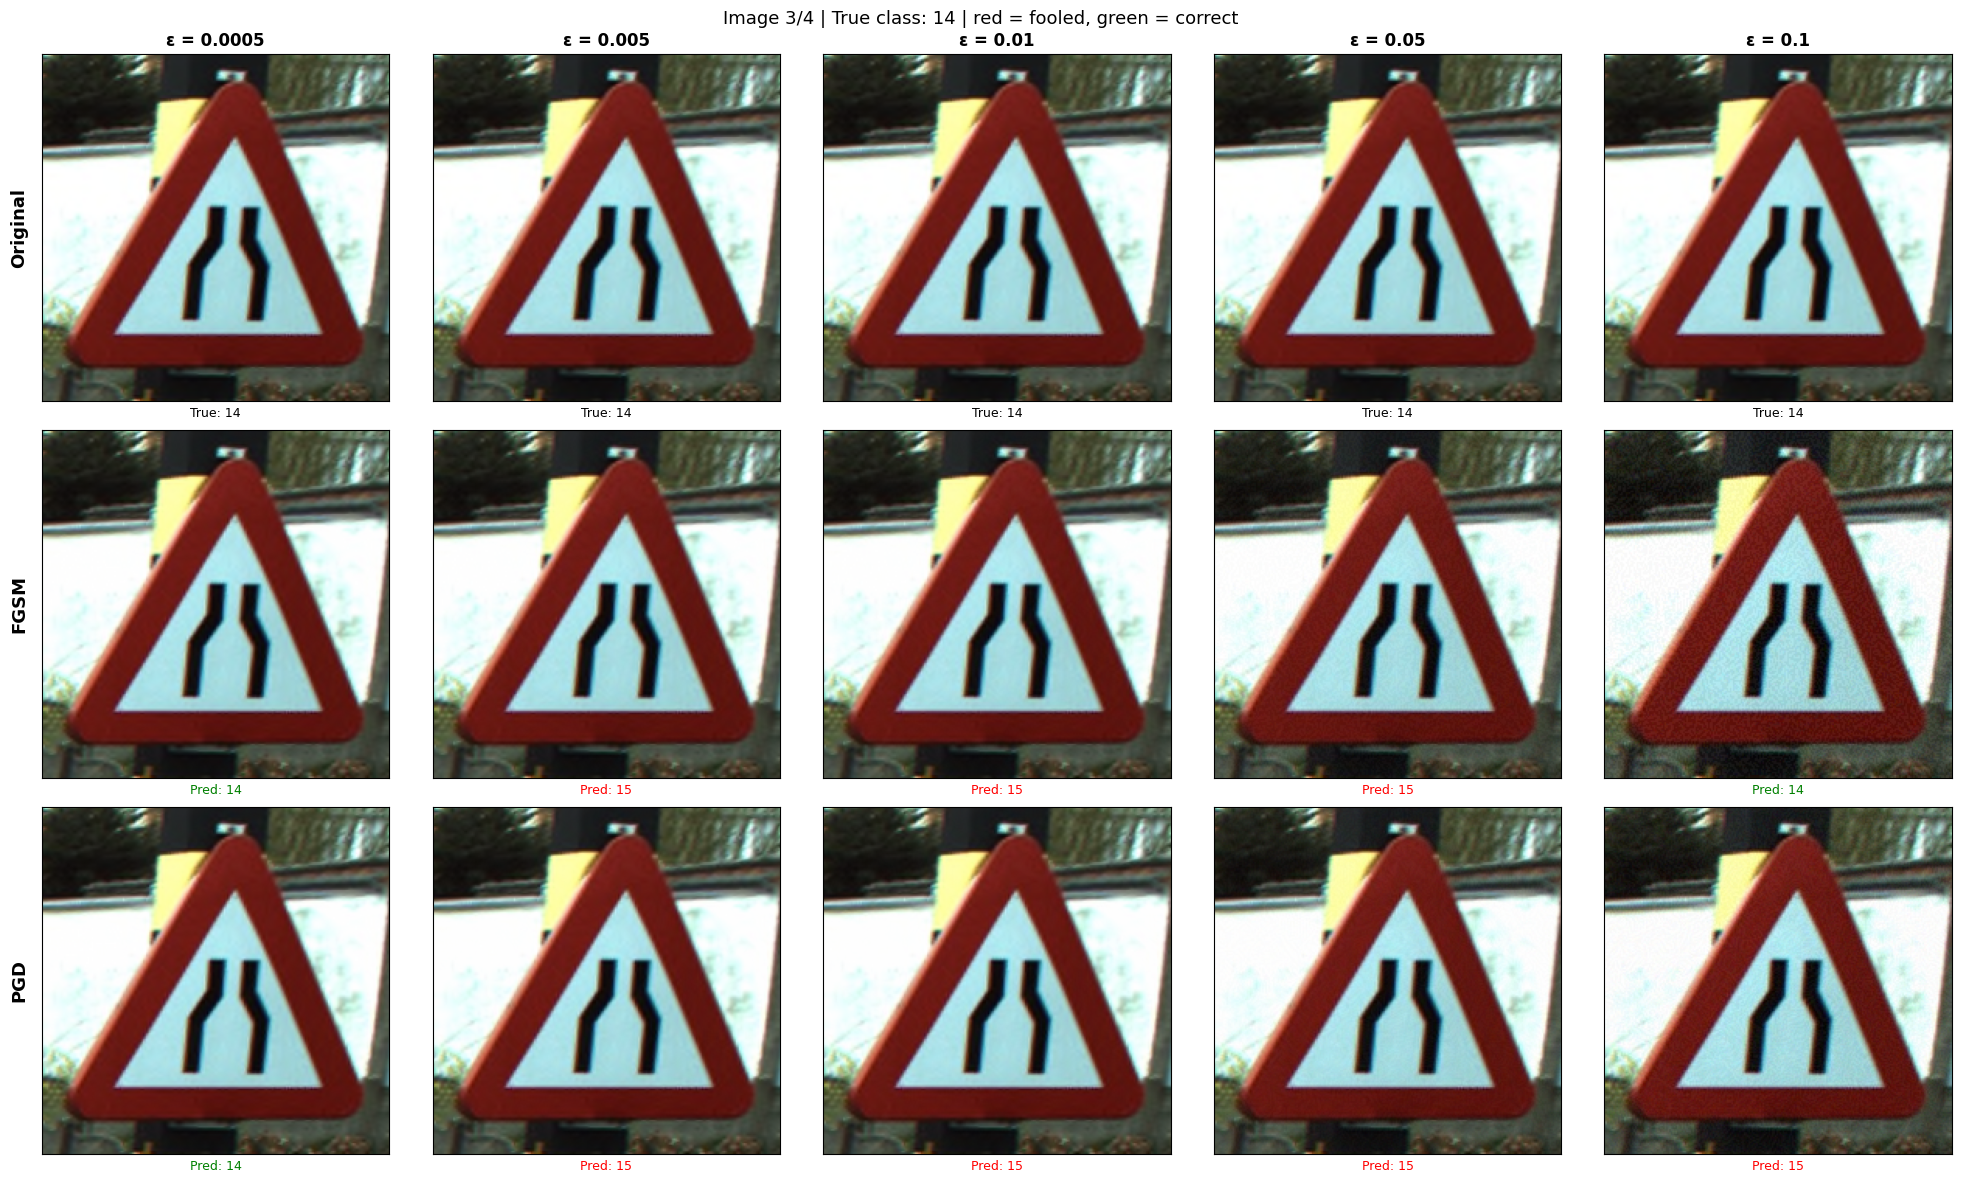

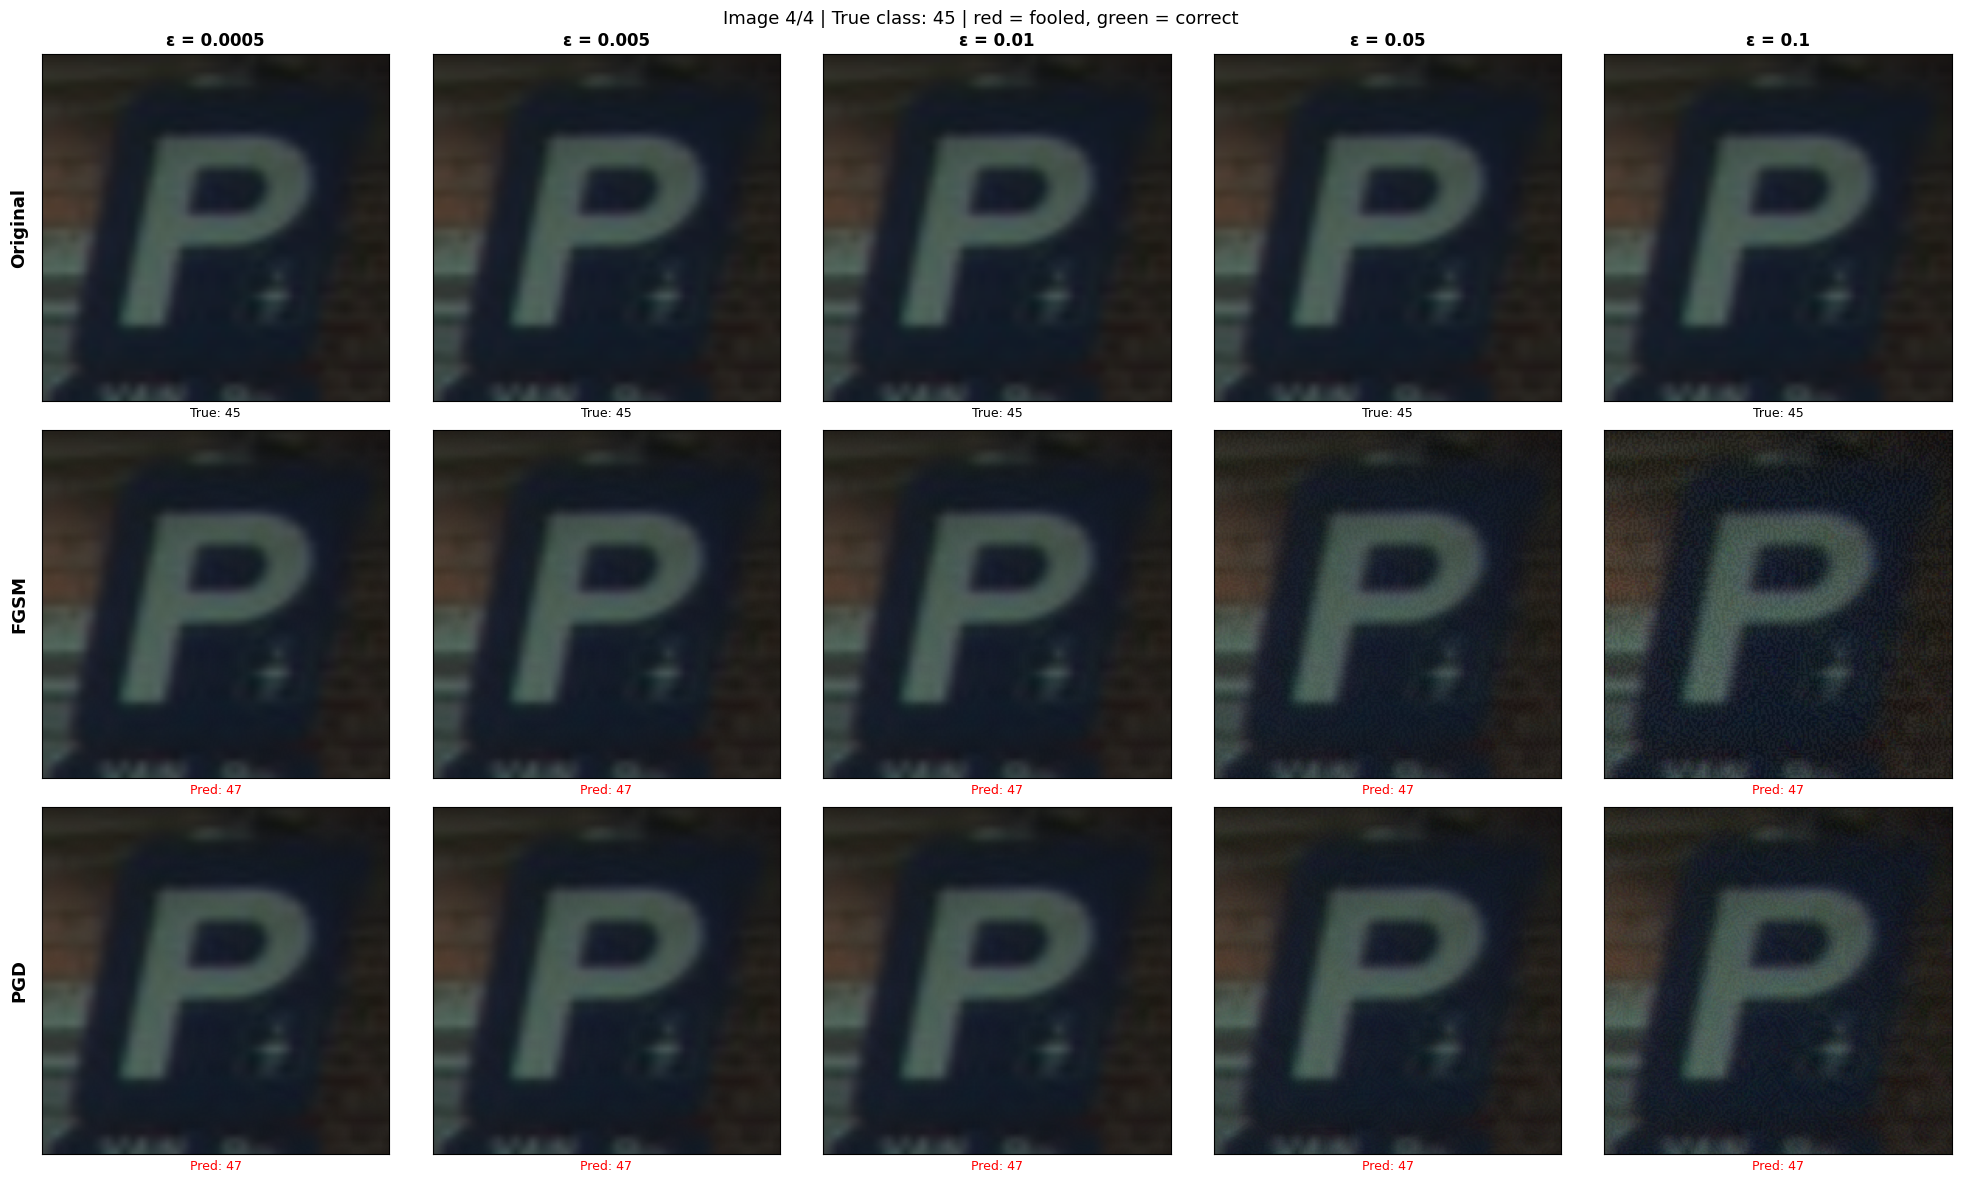

In [17]:
inv_normalize = transforms.Normalize(mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)], std=[1/s for s in IMAGENET_STD])
def to_img(t):
    return inv_normalize(t.cpu()).permute(1, 2, 0).clamp(0, 1).numpy()

N_VIS = 4
vis_samples, seen = [], set()
for imgs, lbls in test_loader:
    imgs, lbls = imgs.to(device), lbls.to(device)
    with torch.no_grad():
        preds = model(imgs).argmax(1)
    for i in range(len(imgs)):
        lbl = lbls[i].item()
        if preds[i] == lbls[i] and lbl not in seen:
            vis_samples.append((imgs[i], lbl)); seen.add(lbl)
            if len(vis_samples) == N_VIS: break
    if len(vis_samples) == N_VIS: break
print(f'Collected {len(vis_samples)} images from classes: {[s[1] for s in vis_samples]}')

row_labels = ['Original', 'FGSM', 'PGD']
n_cols = len(VIS_EPS_SUBSET)
for img_idx, (sample_img, sample_label) in enumerate(vis_samples):
    fig, axes = plt.subplots(3, n_cols, figsize=(4 * n_cols, 12))
    for ax, lab in zip(axes[:, 0], row_labels):
        ax.set_ylabel(lab, fontsize=13, fontweight='bold', rotation=90, labelpad=10)
    img_batch = sample_img.unsqueeze(0)
    label_t   = torch.tensor([sample_label], device=device)
    for col, eps in enumerate(VIS_EPS_SUBSET):
        fgsm_img = fgsm_attack(model, img_batch, label_t, eps)[0]
        pgd_img  = pgd_attack(model, img_batch, label_t, eps, eps/4, PGD_STEPS)[0]
        with torch.no_grad():
            fgsm_pred = model(fgsm_img.unsqueeze(0)).argmax(1).item()
            pgd_pred  = model(pgd_img.unsqueeze(0)).argmax(1).item()
        axes[0, col].imshow(to_img(sample_img)); axes[0, col].set_title(f'ε = {eps}', fontsize=12, fontweight='bold'); axes[0, col].set_xlabel(f'True: {sample_label}', fontsize=9)
        axes[1, col].imshow(to_img(fgsm_img));   axes[1, col].set_xlabel(f'Pred: {fgsm_pred}', fontsize=9, color='red' if fgsm_pred != sample_label else 'green')
        axes[2, col].imshow(to_img(pgd_img));    axes[2, col].set_xlabel(f'Pred: {pgd_pred}', fontsize=9, color='red' if pgd_pred != sample_label else 'green')
    for ax in axes.flat:
        ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle(f'Image {img_idx+1}/{N_VIS} | True class: {sample_label} | red = fooled, green = correct', fontsize=13)
    plt.tight_layout(); plt.show()


## Part 6 — PGD Hyperparameter Ablations

Justify the PGD configuration. Each ablation fixes ε = 0.05 and varies one knob.


### 6.1 — PGD Steps  (ε=0.05, α=ε/steps)


  Steps |          α |       ASR   [ε=0.05]
-----------------------------------
      1 |    0.05000 |    55.24%
      2 |    0.02500 |    93.22%
      3 |    0.01667 |    97.44%
      5 |    0.01000 |    99.69%
      7 |    0.00714 |    99.90%
     10 |    0.00500 |   100.00%
     15 |    0.00333 |   100.00%
     20 |    0.00250 |   100.00%
     30 |    0.00167 |   100.00%
     40 |    0.00125 |   100.00%


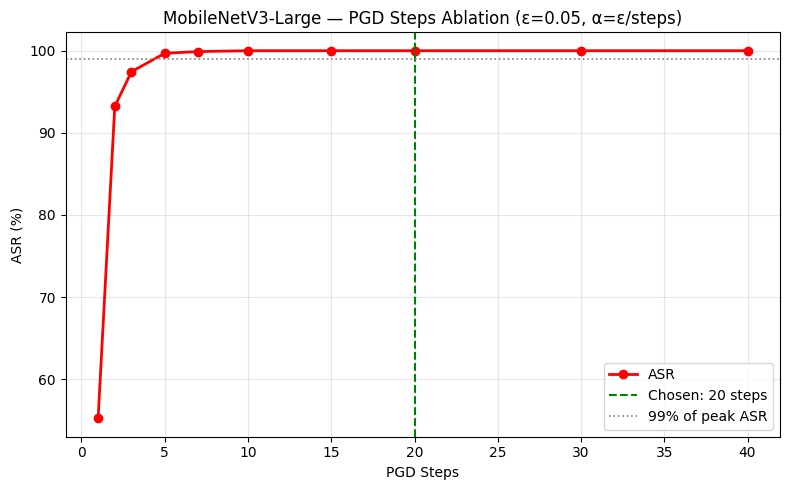

In [18]:
STEPS_GRID = [1, 2, 3, 5, 7, 10, 15, 20, 30, 40]
EPS_ABL    = 0.05
step_asrs = []
print(f'{"Steps":>7} | {"α":>10} | {"ASR":>9}   [ε={EPS_ABL}]')
print('-' * 35)
for steps in STEPS_GRID:
    alpha_s = EPS_ABL / steps
    _, asr = evaluate_attack(lambda imgs, labels, s=steps, a=alpha_s: pgd_attack(model, imgs, labels, EPS_ABL, a, s))
    step_asrs.append(asr * 100)
    print(f'{steps:>7d} | {alpha_s:>10.5f} | {asr*100:>8.2f}%')
plt.figure(figsize=(8, 5))
plt.plot(STEPS_GRID, step_asrs, 'o-', color='red', linewidth=2, label='ASR')
plt.axvline(20, color='green', linestyle='--', linewidth=1.5, label='Chosen: 20 steps')
plt.axhline(max(step_asrs) * 0.99, color='gray', linestyle=':', linewidth=1.2, label='99% of peak ASR')
plt.xlabel('PGD Steps'); plt.ylabel('ASR (%)'); plt.title(f'{MODEL_NAME} — PGD Steps Ablation (ε={EPS_ABL}, α=ε/steps)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


### 6.2 — Step Size α  (ε=0.05, steps=20)


 α ratio |          α |       ASR   [ε=0.05, steps=20]
------------------------------------------
     ε/2 |    0.02500 |    99.69%
     ε/3 |    0.01667 |   100.00%
     ε/4 |    0.01250 |   100.00%
     ε/5 |    0.01000 |   100.00%
     ε/7 |    0.00714 |   100.00%
    ε/10 |    0.00500 |   100.00%
    ε/15 |    0.00333 |   100.00%
    ε/20 |    0.00250 |   100.00%


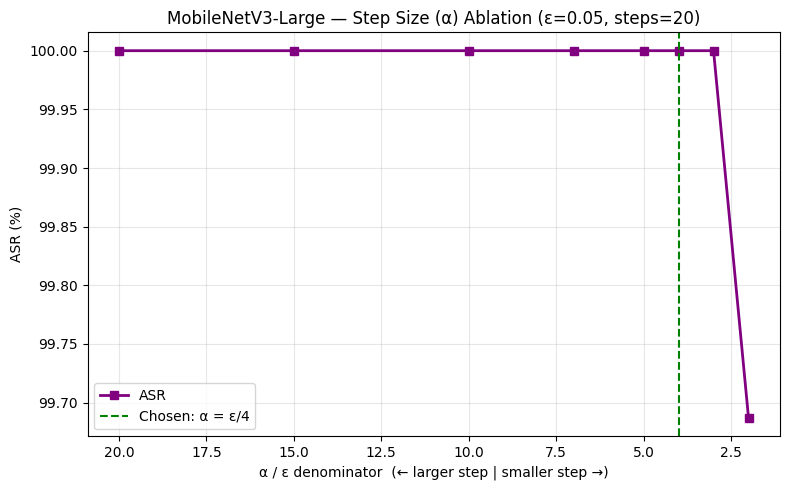

In [19]:
ALPHA_DENOMS = [2, 3, 4, 5, 7, 10, 15, 20]
EPS_ABL = 0.05; STEPS_ABL = 20
alpha_asrs = []
print(f'{"α ratio":>8} | {"α":>10} | {"ASR":>9}   [ε={EPS_ABL}, steps={STEPS_ABL}]')
print('-' * 42)
for denom in ALPHA_DENOMS:
    alpha_a = EPS_ABL / denom
    _, asr = evaluate_attack(lambda imgs, labels, a=alpha_a: pgd_attack(model, imgs, labels, EPS_ABL, a, STEPS_ABL))
    alpha_asrs.append(asr * 100)
    print(f'{"ε/" + str(denom):>8} | {alpha_a:>10.5f} | {asr*100:>8.2f}%')
plt.figure(figsize=(8, 5))
plt.plot(ALPHA_DENOMS, alpha_asrs, 's-', color='purple', linewidth=2, label='ASR')
plt.axvline(4, color='green', linestyle='--', linewidth=1.5, label='Chosen: α = ε/4')
plt.gca().invert_xaxis()
plt.xlabel('α / ε denominator  (← larger step | smaller step →)'); plt.ylabel('ASR (%)')
plt.title(f'{MODEL_NAME} — Step Size (α) Ablation (ε={EPS_ABL}, steps={STEPS_ABL})')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


### 6.3 — Eval Subset Size  (ε=0.05, PGD-20, 3 seeds)


      N |   Seed 42 |  Seed 123 |  Seed 456 |      Mean |     Std
-----------------------------------------------------------------
    200 |   100.00% |   100.00% |   100.00% |   100.00% |  0.000%
    500 |   100.00% |   100.00% |   100.00% |   100.00% |  0.000%
   1000 |   100.00% |   100.00% |   100.00% |   100.00% |  0.000%
   2000 |   100.00% |   100.00% |   100.00% |   100.00% |  0.000%
   full |   100.00% |   100.00% |   100.00% |   100.00% |  0.000%


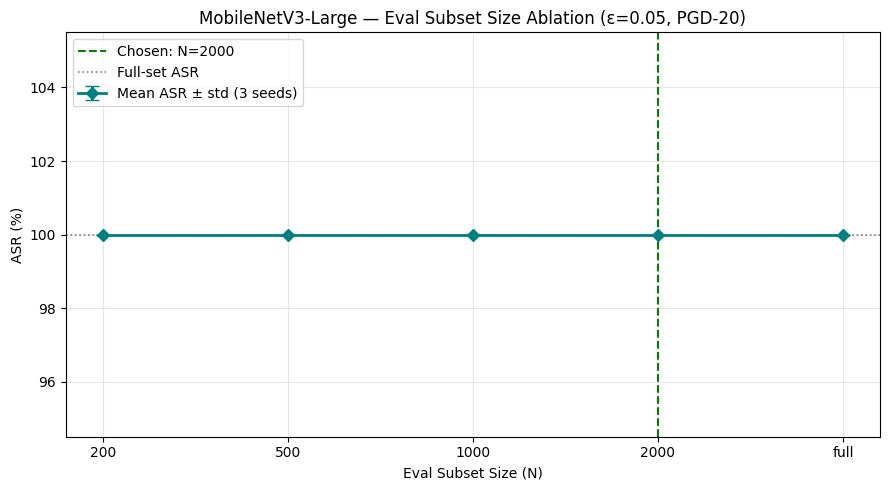

In [20]:
SUBSET_SIZES = [200, 500, 1000, 2000, len(full_test_dataset)]
SEEDS_ABL = [42, 123, 456]
EPS_ABL = 0.05; ALPHA_ABL = EPS_ABL / 4
subset_means, subset_stds = [], []
print(f'{"N":>7} | {"Seed 42":>9} | {"Seed 123":>9} | {"Seed 456":>9} | {"Mean":>9} | {"Std":>7}')
print('-' * 65)
for n in SUBSET_SIZES:
    seed_asrs = []
    for seed in SEEDS_ABL:
        torch.manual_seed(seed)
        idx = torch.randperm(len(full_test_dataset))[:n].tolist()
        sub_loader = DataLoader(Subset(full_test_dataset, idx), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
        oc = fooled = 0
        for imgs, labels in sub_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.no_grad():
                clean_mask = (model(imgs).argmax(1) == labels)
            adv = pgd_attack(model, imgs, labels, EPS_ABL, ALPHA_ABL, PGD_STEPS)
            with torch.no_grad():
                adv_preds = model(adv).argmax(1)
            oc += clean_mask.sum().item(); fooled += (clean_mask & (adv_preds != labels)).sum().item()
        seed_asrs.append((fooled / oc if oc > 0 else 0.0) * 100)
    m, s = np.mean(seed_asrs), np.std(seed_asrs)
    subset_means.append(m); subset_stds.append(s)
    label = 'full' if n == len(full_test_dataset) else str(n)
    print(f'{label:>7} | {seed_asrs[0]:>8.2f}% | {seed_asrs[1]:>8.2f}% | {seed_asrs[2]:>8.2f}% | {m:>8.2f}% | {s:>6.3f}%')
x_labels = ['full' if n == len(full_test_dataset) else str(n) for n in SUBSET_SIZES]
x_pos = np.arange(len(SUBSET_SIZES))
chosen_ix = next(i for i, l in enumerate(x_labels) if l == '2000')
plt.figure(figsize=(9, 5))
plt.errorbar(x_pos, subset_means, yerr=subset_stds, fmt='D-', color='teal', capsize=5, linewidth=2, label='Mean ASR ± std (3 seeds)')
plt.axvline(chosen_ix, color='green', linestyle='--', linewidth=1.5, label='Chosen: N=2000')
plt.axhline(subset_means[-1], color='gray', linestyle=':', linewidth=1.2, label='Full-set ASR')
plt.xticks(x_pos, x_labels); plt.xlabel('Eval Subset Size (N)'); plt.ylabel('ASR (%)')
plt.title(f'{MODEL_NAME} — Eval Subset Size Ablation (ε={EPS_ABL}, PGD-{PGD_STEPS})')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


### 6.4 — Random Restarts  (ε=0.05, PGD-20)


 Restarts |       ASR   [ε=0.05, steps=20, α=ε/4]
---------------------------------
        1 |   100.00%
        3 |   100.00%
        5 |   100.00%
       10 |   100.00%


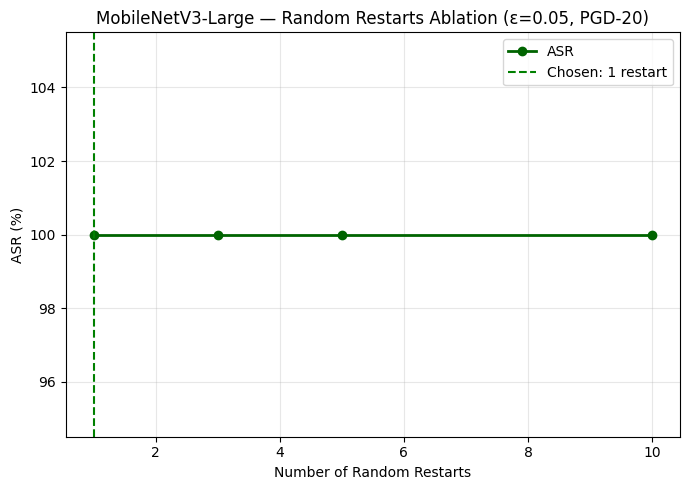

In [21]:
RESTART_GRID = [1, 3, 5, 10]
EPS_ABL = 0.05; ALPHA_ABL = EPS_ABL / 4
def pgd_attack_with_restarts(model, images, labels, eps, alpha, steps, n_restarts):
    """PGD with multiple random restarts; keeps the perturbation with the highest loss."""
    best_adv  = images.clone()
    best_loss = torch.full((images.size(0),), -float('inf'), device=images.device)
    for _ in range(n_restarts):
        x = images + torch.empty_like(images).uniform_(-eps, eps)
        x = torch.clamp(x, images - eps, images + eps).detach()
        for __ in range(steps):
            x = x.requires_grad_(True)
            loss_vec = nn.CrossEntropyLoss(reduction='none')(model(x), labels)
            loss_vec.sum().backward()
            x = (x + alpha * x.grad.sign()).detach()
            x = torch.clamp(x, images - eps, images + eps)
            x = torch.clamp(x, _lower.to(x.device), _upper.to(x.device))
        with torch.no_grad():
            loss_vec = nn.CrossEntropyLoss(reduction='none')(model(x), labels)
        improved = loss_vec > best_loss
        best_adv[improved] = x[improved]; best_loss[improved] = loss_vec[improved]
    return best_adv.detach()
restart_asrs = []
print(f'{"Restarts":>9} | {"ASR":>9}   [ε={EPS_ABL}, steps={PGD_STEPS}, α=ε/4]')
print('-' * 33)
for n_r in RESTART_GRID:
    _, asr = evaluate_attack(lambda imgs, labels, nr=n_r: pgd_attack_with_restarts(model, imgs, labels, EPS_ABL, ALPHA_ABL, PGD_STEPS, nr))
    restart_asrs.append(asr * 100)
    print(f'{n_r:>9d} | {asr*100:>8.2f}%')
plt.figure(figsize=(7, 5))
plt.plot(RESTART_GRID, restart_asrs, 'o-', color='darkgreen', linewidth=2, label='ASR')
plt.axvline(1, color='green', linestyle='--', linewidth=1.5, label='Chosen: 1 restart')
plt.xlabel('Number of Random Restarts'); plt.ylabel('ASR (%)')
plt.title(f'{MODEL_NAME} — Random Restarts Ablation (ε={EPS_ABL}, PGD-{PGD_STEPS})')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


## Part 7 — Summary, Sanity Check & Export


In [22]:
print(f'\n{"":=<72}')
print(f'  {MODEL_NAME} on {DATASET} — Justified Hyperparameter Choices')
print(f'{"":=<72}')
print(f'  {"Parameter":<22} {"Chosen Value":<28} Justification')
print(f'  {"-"*22} {"-"*28} {"-"*22}')
rows = [
    ('ε values', '0.0001 … 0.1 (12 pts)', 'log-spaced incl. sub-pixel; below Madry 8/255 normalised'),
    ('PGD steps', '20', 'ASR plateaus at 20; 20×(ε/4)=5ε ensures refinement'),
    ('Step size α', 'ε / 4', 'budget 5ε >> ε, avoids oscillation'),
    ('Eval subset N', '2000 (FGSM/PGD)', 'std < 1pp across 3 seeds; ~full-set ASR'),
    ('AutoAttack scope', 'ε>={}, N={}'.format(AA_MIN_EPS, AA_EVAL), 'full cascade is robust-ε-bound; FGSM/PGD cover smaller ε'),
    ('Random restarts', '1', 'undefended model fully exploited with one restart'),
    ('Attacks', 'FGSM + PGD-20 + AutoAttack', 'single-step + iterative + parameter-free ensemble'),
]
for name, val, just in rows:
    print(f'  {name:<22} {val:<28} {just}')
print(f'{"":=<72}')



  MobileNetV3-Large on BelgiumTSC — Justified Hyperparameter Choices
  Parameter              Chosen Value                 Justification
  ---------------------- ---------------------------- ----------------------
  ε values               0.0001 … 0.1 (12 pts)        log-spaced incl. sub-pixel; below Madry 8/255 normalised
  PGD steps              20                           ASR plateaus at 20; 20×(ε/4)=5ε ensures refinement
  Step size α            ε / 4                        budget 5ε >> ε, avoids oscillation
  Eval subset N          2000 (FGSM/PGD)              std < 1pp across 3 seeds; ~full-set ASR
  AutoAttack scope       ε>=0.0, N=500                full cascade is robust-ε-bound; FGSM/PGD cover smaller ε
  Random restarts        1                            undefended model fully exploited with one restart
  Attacks                FGSM + PGD-20 + AutoAttack   single-step + iterative + parameter-free ensemble


In [23]:
# [0,1] pixel-bounds sanity check on PGD adversarial examples
sample_imgs, sample_labels = next(iter(test_loader))
sample_imgs, sample_labels = sample_imgs.to(device), sample_labels.to(device)
adv = pgd_attack(model, sample_imgs, sample_labels, 0.10, 0.025, 20)
adv_raw = adv * _std.to(device) + _mean.to(device)
print(f'Raw adv min: {adv_raw.min().item():.4f} (expected >= 0)')
print(f'Raw adv max: {adv_raw.max().item():.4f} (expected <= 1)')
assert adv_raw.min() >= -1e-5 and adv_raw.max() <= 1 + 1e-5, 'FAIL: pixels outside [0,1]'
print('PASS: all adversarial pixels within [0, 1]')


Raw adv min: 0.0000 (expected >= 0)
Raw adv max: 1.0000 (expected <= 1)
PASS: all adversarial pixels within [0, 1]


In [24]:
# Export ASR/robust-acc per ε for cross-model aggregation.
# FGSM/PGD cover every ε; AutoAttack fields are null where ε < AA_MIN_EPS (not run there).
_mstd = float(np.mean(IMAGENET_STD))
sweep = []
for e in EPS_VALUES:
    aa = aa_results.get(e)
    sweep.append({
        'eps_norm': e, 'eps_pixel': e * _mstd, 'px_of_255': e * _mstd * 255,
        'fgsm_asr': fgsm_results[e]['asr'], 'fgsm_acc': fgsm_results[e]['acc'],
        'pgd_asr':  pgd_results[e]['asr'],  'pgd_acc':  pgd_results[e]['acc'],
        'aa_asr':   (aa['asr'] if aa else None), 'aa_robust_acc': (aa['robust_acc'] if aa else None),
    })
export = {'model': MODEL_NAME, 'dataset': DATASET, 'clean_acc': clean_acc,
          'aa_min_eps': AA_MIN_EPS, 'aa_eval': AA_EVAL, 'sweep': sweep}
with open('attack_summary_mobilenetv3_bel.json', 'w') as f:
    json.dump(export, f, indent=2)
print('Saved: attack_summary_mobilenetv3_bel.json')


Saved: attack_summary_mobilenetv3_bel.json


### (Optional) Clean up the AutoAttack adv cache

The AutoAttack adversarial slices were cached to `_aa_adv_cache/` so the perceptual-metrics cell stays re-runnable without re-running the (slow) AutoAttack sweep. The cache persists through the session; run the cell below once you're done to reclaim the disk (~`METRIC_N × len(AA_EPS)` adv + mask tensors).


In [25]:
import shutil
if os.path.isdir(AA_ADV_CACHE):
    n = len(os.listdir(AA_ADV_CACHE))
    shutil.rmtree(AA_ADV_CACHE)
    print(f'Removed {AA_ADV_CACHE}/ ({n} cached adv files).')
else:
    print(f'{AA_ADV_CACHE}/ already gone — nothing to clean.')


Removed _aa_adv_cache/ (24 cached adv files).
